In [1]:
# Ô lệnh do kaggle_run.sh chèn vào — đặt chế độ chạy trước khi notebook đọc biến này.
import os
os.environ['SMOKE_TEST'] = '0'
print('SMOKE_TEST =', os.environ['SMOKE_TEST'], '->', 'thử nhanh' if os.environ['SMOKE_TEST'] == '1' else 'chạy đầy đủ')


SMOKE_TEST = 0 -> chạy đầy đủ


# Lazada Uplift — 04c · Holdout & Bàn giao

Mảnh cuối. Đây là notebook **duy nhất** trong cả pipeline nạp `rct_holdout.parquet`.

Ba việc:

1. Kiểm rằng chuỗi 04a → 04b → 04c khớp nhau, và **mã băm quyết định của 04b chưa bị đụng vào**
2. Mở `rct_holdout` đúng một lần: bảng benchmark cuối, mô phỏng chính sách, phân tích nhóm persuadables
3. Đóng gói bàn giao: `model.pkl`, `model_booster.txt`, `feature_contract.json`, `golden_predictions.csv`, `metadata.json`

> ## ⚠️ Điểm không quay lại
>
> Từ Phần 3 trở đi, tập `rct_holdout` được mở ra. **Không được đổi mô hình, đổi siêu tham số hay đổi bộ đặc trưng sau khi nhìn thấy những con số ở đây.** Mọi lựa chọn đã chốt xong ở 04b và đã bị đóng băng vào `decisions_locked.json`.
>
> Notebook này không có khả năng chọn lại gì cả: nó không huấn luyện mô hình mới, không quét đặc trưng, và Bước 24 tính lại mã băm bản khóa trước khi ghi bất kỳ file bàn giao nào. Nếu ai đó sửa quyết định sau khi nhìn kết quả, ô lệnh đó dừng.

---
# Phần 1 — Thiết lập và kiểm chuỗi

### Bước 1 — Import thư viện

In [2]:
import os
if os.path.exists('/kaggle'):
    get_ipython().run_line_magic('pip', 'install -q econml optuna mlflow')
else:
    print('Local: dependencies are managed by uv (uv sync --frozen).')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 86.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.2/216.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3

In [3]:
import os
import json
import time
import pickle
import hashlib
import shutil
import cloudpickle
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from econml.dml import LinearDML, NonParamDML, CausalForestDML

warnings.filterwarnings('ignore')

IS_KAGGLE = os.path.exists('/kaggle/input')

if IS_KAGGLE:
    print("📌 Đang chạy trên Kaggle Environment")
    # Không gõ cứng đường dẫn: Kaggle mount dataset ở chỗ khác nhau tuỳ cách gắn.
    # Tìm thẳng thư mục nào chứa train.parquet.
    import glob
    _ung_vien = [os.path.dirname(f) for f in
                 glob.glob('/kaggle/input/**/train.parquet', recursive=True)]
    if not _ung_vien:
        raise FileNotFoundError(
            'Không tìm thấy train.parquet trong /kaggle/input. Kiểm tra đã gắn dataset chưa.')
    DATA_DIR = _ung_vien[0]
    ART_DIR = '/kaggle/working/artifacts'
    FIG_DIR = '/kaggle/working/reports/figures'
else:
    print("📌 Đang chạy trên máy Local")
    ROOT = '..' if os.path.basename(os.getcwd()) == 'notebooks' else '.'
    DATA_DIR = os.path.join(ROOT, 'dataset')
    ART_DIR = os.path.join(ROOT, 'artifacts')
    FIG_DIR = os.path.join(ROOT, 'reports', 'figures')

os.makedirs(ART_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)

# np.trapz đã đổi tên ở NumPy 2 — dùng bản nào có sẵn
TRAPZ = getattr(np, 'trapezoid', None) or np.trapz

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titleweight'] = 'bold'
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

print(f"DATA_DIR: {DATA_DIR}")
print(f"ART_DIR : {ART_DIR}")

📌 Đang chạy trên Kaggle Environment
DATA_DIR: /kaggle/input/datasets/hatrungkienhatuki/lazada-uplift-data
ART_DIR : /kaggle/working/artifacts


In [4]:
import glob


def tim_file(ten, bat_buoc=True):
    """Tìm một file bàn giao: ưu tiên artifacts local, rồi tới output kernel khác trên Kaggle.

    Trên Kaggle, đầu ra của notebook trước được gắn vào qua kernel_sources và nằm
    dưới /kaggle/input/<slug>/. Tìm thấy nhiều bản thì in hết ra — hai bản khác nhau
    nghĩa là đang có bản cũ lẫn vào, và chọn nhầm bản cũ là lỗi không báo gì cả.
    """
    ung_vien = [os.path.join(ART_DIR, ten)]
    ung_vien += sorted(glob.glob(f'/kaggle/input/**/{ten}', recursive=True))
    ung_vien = [p for p in ung_vien if os.path.exists(p)]
    if not ung_vien:
        if bat_buoc:
            raise FileNotFoundError(
                f'Không tìm thấy {ten}. Chạy notebook sinh ra nó trước, hoặc gắn output '
                'của kernel đó vào qua kernel_sources.')
        return None
    if len(ung_vien) > 1:
        print(f'!!! Tìm thấy {len(ung_vien)} bản {ten} — kiểm tra có bản cũ lẫn vào không:')
        for p in ung_vien:
            print('   ', p)
    return ung_vien[0]


def bam_dac_trung(feats):
    """Vân tay của tập đặc trưng — ba notebook phải khớp nhau."""
    return hashlib.sha256(','.join(feats).encode()).hexdigest()[:16]


print('Đã định nghĩa tim_file và bam_dac_trung')

Đã định nghĩa tim_file và bam_dac_trung


### Bước 2 — Chế độ chạy

Notebook này không huấn luyện gì nên chạy rất nhanh; `N_BOOT` là thứ duy nhất đáng kể về thời gian.

`GOLDEN_N` là số dòng mẫu ghi vào `golden_predictions.csv` để phía DE tự đối chiếu.

In [5]:
SMOKE_TEST = os.environ.get('SMOKE_TEST', '1').lower() not in ('0', 'false', 'no')

N_BOOT = 100 if SMOKE_TEST else 1_000
GOLDEN_N = 1_000

RUN_MODE = 'smoke_test' if SMOKE_TEST else 'full'

print('=' * 68)
print(f'  04c — HOLDOUT & BÀN GIAO   |   CHẾ ĐỘ: {RUN_MODE.upper()}')
print(f'  Bootstrap        : {N_BOOT:,} lần')
print(f'  Golden prediction: {GOLDEN_N:,} dòng')
if SMOKE_TEST:
    print('  >>> KẾT QUẢ CHỈ ĐỂ KIỂM TRA CODE, KHÔNG DÙNG BÁO CÁO <<<')
print('=' * 68)

  04c — HOLDOUT & BÀN GIAO   |   CHẾ ĐỘ: FULL
  Bootstrap        : 1,000 lần
  Golden prediction: 1,000 dòng


### Bước 3 — Nạp 04a, 04b và kiểm chuỗi

Bốn phép kiểm trước khi mở holdout. Ba cái đầu bắt lỗi ghép nhầm kết quả của hai lần chạy khác nhau; cái thứ tư là chốt cổng của cả thiết kế:

| Kiểm | Bắt được lỗi gì |
|---|---|
| `run_id` 04a ghi trong `04b_select_meta.json` khớp `04a_train_meta.json` | Gắn nhầm output 04a của lần chạy khác |
| Mã băm tập đặc trưng khớp ở cả ba nơi | Notebook 02 đã đổi danh sách cột sau khi 04a chạy |
| `run_mode` của cả chuỗi | Trộn kết quả smoke với kết quả full |
| **Mã băm quyết định tính lại từ nội dung `decisions_locked.json`** | Có người sửa quán quân hoặc `k` sau khi 04b đã khóa |

In [6]:
# --- đầu ra của 04a và 04b ---
train_meta = json.load(open(tim_file('04a_train_meta.json'), encoding='utf-8'))
select_meta = json.load(open(tim_file('04b_select_meta.json'), encoding='utf-8'))
khoa = json.load(open(tim_file('decisions_locked.json'), encoding='utf-8'))

with open(tim_file('04b_model_ban_giao.pkl'), 'rb') as f:
    MO_HINH_GIAO = pickle.load(f)

# --- quyết định đã khóa ---
quan_quan = khoa['quan_quan']
K_CHOT = int(khoa['k_chot'])
FEAT_CHOT = khoa['dac_trung_ban_giao']
KHOA_HASH = khoa['ma_bam']
ly_do = khoa['cach_chon_k']

# --- đặc trưng và dữ liệu ---
finfo = json.load(open(tim_file('feature_info.json'), encoding='utf-8'))
FEATS = finfo['tat_ca_dac_trung']
N_FEAT = len(FEATS)
IDX_CHOT = [FEATS.index(f) for f in FEAT_CHOT]

MODELS = ['SLearner', 'TLearner', 'DRLearner',
          'LinearDML', 'NonParamDML', 'CausalForestDML']
OK_MODELS = [m for m in MODELS if m in train_meta['mo_hinh']]
thoi_gian = {m: train_meta['mo_hinh'][m]['giay'] for m in OK_MODELS}
n_dong_fit = {m: train_meta['mo_hinh'][m]['so_dong_huan_luyen'] for m in OK_MODELS}

# --- bốn phép kiểm chuỗi ---
assert select_meta['run_id_04a'] == train_meta['run_id'], \
    '04b dùng kết quả của một lần chạy 04a khác — gắn lại đúng output'
assert train_meta['ma_bam_dac_trung'] == select_meta['ma_bam_dac_trung'] == bam_dac_trung(FEATS), \
    'Tập đặc trưng lệch giữa các notebook'
assert select_meta['ma_bam_quyet_dinh'] == KHOA_HASH

goi = {k: v for k, v in khoa.items() if k not in ('thoi_diem_khoa', 'ma_bam')}
hash_kiem = hashlib.sha256(
    json.dumps(goi, ensure_ascii=False, sort_keys=True).encode('utf-8')).hexdigest()[:16]
assert hash_kiem == KHOA_HASH, (
    'decisions_locked.json đã bị sửa sau khi 04b khóa. Kết quả holdout sẽ không còn '
    'giá trị khoa học — phải chạy lại từ 04b.')

assert set(FEAT_CHOT).issubset(set(FEATS)) and len(FEAT_CHOT) == K_CHOT
assert not any(f.startswith('fe_') for f in FEAT_CHOT)

print('🔗 Chuỗi notebook khớp:')
print(f'   04a run_id : {train_meta["run_id"]}')
print(f'   04b run_id : {select_meta["run_id_04b"]}')
print(f'   mã băm quyết định: {KHOA_HASH}  (tính lại khớp)')
print()
print(f'Quán quân đã khóa   : {quan_quan}')
print(f'Đặc trưng bàn giao  : {K_CHOT}/{N_FEAT}  ({ly_do})')
print(f'run_mode            : 04a={train_meta["run_mode"]} · 04b={select_meta["run_mode"]} '
      f'· 04c={RUN_MODE}')
if len({train_meta['run_mode'], select_meta['run_mode'], RUN_MODE}) > 1:
    print('>>> CẢNH BÁO: ba notebook chạy ở chế độ khác nhau — không dùng số này để báo cáo <<<')

🔗 Chuỗi notebook khớp:
   04a run_id : full-20260819-024811-f35fc7
   04b run_id : full-20260819-041542-60b756
   mã băm quyết định: 3960fbe51566cb1a  (tính lại khớp)

Quán quân đã khóa   : DRLearner
Đặc trưng bàn giao  : 69/69  (k nhỏ nhất thỏa mãn cả ba điều kiện (có tính bền))
run_mode            : 04a=full · 04b=full · 04c=full


In [7]:
_cache_mo_hinh = {}


def nap_mo_hinh(ten):
    """Nạp mô hình 04a đã huấn luyện — dùng để chấm 6 mô hình trên holdout."""
    if ten not in _cache_mo_hinh:
        with open(tim_file(f'04a_model_{ten}.pkl'), 'rb') as f:
            _cache_mo_hinh[ten] = pickle.load(f)
    return _cache_mo_hinh[ten]


train = pd.read_parquet(os.path.join(DATA_DIR, 'train.parquet'))
val = pd.read_parquet(os.path.join(DATA_DIR, 'val.parquet'))
rct_sel = pd.read_parquet(os.path.join(DATA_DIR, 'rct_select.parquet'))

full = pd.concat([train, val], ignore_index=True)      # dùng cho giá trị mặc định của contract
X_sel = rct_sel[FEATS].values.astype(np.float32)

print(f'Train + Val : {len(full):,} dòng (chỉ dùng để tính trung vị cho feature contract)')
print(f'rct_select  : {len(rct_sel):,} dòng')
print('rct_holdout : chưa nạp — chỉ mở ở Phần 3')

Train + Val : 926,669 dòng (chỉ dùng để tính trung vị cho feature contract)
rct_select  : 90,834 dòng
rct_holdout : chưa nạp — chỉ mở ở Phần 3


---
# Phần 2 — Bộ metric và bốn phép kiểm chứng

Đây là phần quan trọng nhất của notebook, và là phần phải làm **trước** khi nhìn bất kỳ kết quả mô
hình nào. Lý do đơn giản: nếu công thức Qini sai thì mọi kết luận rút ra từ nó cũng sai theo, mà cái
sai đó rất khó phát hiện vì bảng kết quả vẫn in ra những con số trông hợp lý.

Cách phòng: viết metric xong thì thử ngược bằng những trường hợp đã biết trước đáp án.

### Bước 4 — Đường Qini và đường Cumulative Gain

Cả hai đường đều xây theo cùng một ý tưởng: sắp khách hàng giảm dần theo CATE dự đoán, rồi hỏi
*"nếu chỉ phát voucher cho k% đứng đầu thì được thêm bao nhiêu đơn hàng?"*.

Vướng mắc là trong nhóm k% đó có cả người thực sự nhận voucher lẫn người không, và số lượng hai
nhóm không bằng nhau. Hai đường xử lý chuyện đó theo hai cách khác nhau:

$$\text{Qini}(k) = Y^T_k - Y^C_k \cdot \frac{N^T_k}{N^C_k}
\qquad
\text{Gain}(k) = \left(\frac{Y^T_k}{N^T_k} - \frac{Y^C_k}{N^C_k}\right)(N^T_k + N^C_k)$$

Qini quy số đơn của nhóm control về cùng cỡ với nhóm treatment. Cumulative Gain lấy hiệu hai *tỉ lệ*
rồi nhân ngược lên cỡ nhóm. Khi hai nhóm cân bằng thì hai đường gần trùng nhau; khi lệch nhiều thì
Qini ổn định hơn ở đầu đường cong, nên nó được chọn làm metric chính.

Hai chi tiết kỹ thuật:

- **Phá thế hòa có seed.** Nhiều mô hình cho ra CATE trùng nhau ở hàng loạt dòng. Nếu để `argsort`
  tự xử thì thứ tự phụ thuộc thứ tự dòng trong file, và một mô hình dự đoán hằng số có thể ăn may
  điểm cao. Xáo ngẫu nhiên trong nhóm hòa, có seed để chạy lại ra đúng kết quả cũ.
- **Chia cho cỡ mẫu.** Đường cong tính theo số đơn tuyệt đối sẽ phụ thuộc cỡ tập. Chia cho `n` để
  so sánh được giữa `rct_select` và `rct_holdout`.

In [8]:
def _sap_xep(y, w, score, seed=SEED):
    '''Sắp giảm dần theo score, phá thế hòa ngẫu nhiên có seed.'''
    n = len(y)
    rng = np.random.RandomState(seed)
    order = np.lexsort((rng.rand(n), -np.asarray(score, dtype=float)))
    y_, w_ = np.asarray(y)[order], np.asarray(w)[order]
    return (np.cumsum(w_), np.cumsum(1 - w_),
            np.cumsum(y_ * w_), np.cumsum(y_ * (1 - w_)))


def qini_curve(y, w, score, seed=SEED):
    '''Trả về (x = tỉ lệ dân số được nhắm, y = số đơn tăng thêm trên mỗi người).'''
    nt, nc, yt, yc = _sap_xep(y, w, score, seed)
    n = len(y)
    ty_le = np.divide(nt, nc, out=np.zeros(n), where=nc > 0)
    return np.arange(1, n + 1) / n, (yt - yc * ty_le) / n


def gain_curve(y, w, score, seed=SEED):
    n = len(y)
    nt, nc, yt, yc = _sap_xep(y, w, score, seed)
    r_t = np.divide(yt, nt, out=np.zeros(n), where=nt > 0)
    r_c = np.divide(yc, nc, out=np.zeros(n), where=nc > 0)
    return np.arange(1, n + 1) / n, (r_t - r_c) * (nt + nc) / n


print('Đã định nghĩa qini_curve và gain_curve')

Đã định nghĩa qini_curve và gain_curve


### Bước 5 — Hệ số Qini và AUUC

Đường cong là một dãy số, cần thu về một con số duy nhất để xếp hạng.

Mốc so sánh là **đường chéo ngẫu nhiên**: nếu phát voucher cho một nhóm ngẫu nhiên k% thì thu được
đúng k% của tổng hiệu ứng, tức một đường thẳng nối gốc tọa độ tới điểm cuối. Diện tích giữa đường
cong của mô hình và đường chéo đó chính là phần giá trị mà việc xếp hạng mang lại.

Diện tích thô có đơn vị "đơn hàng trên mỗi người", cỡ khoảng $10^{-4}$ trên bộ dữ liệu này —
đúng nhưng khó đọc. Nên chia thêm cho diện tích của một **xếp hạng biết trước đáp án**:

```
score_oracle = +1 nếu (nhận voucher và có mua)
               -1 nếu (không nhận voucher mà vẫn mua)
                0 còn lại
```

Xếp hạng này đẩy toàn bộ người "mua khi có voucher" lên đầu và người "mua kể cả khi không có voucher"
xuống cuối, tức là đường Qini dốc nhất có thể đạt được trên chính tập dữ liệu đó. Nó nhìn vào nhãn
thật nên không phải mô hình — chỉ là **trần trên** để quy về thang 0–1.

Với cách chuẩn hóa này: xếp hạng ngẫu nhiên cho khoảng 0, xếp hạng biết trước cho đúng 1,0. Mô hình
thật nằm đâu đó ở giữa, và con số đọc ra là *"đạt được bao nhiêu phần trăm của mức tốt nhất có thể"*.

In [9]:
def oracle_score(y, w):
    '''Xếp hạng biết trước đáp án — trần trên để chuẩn hóa, không phải mô hình.'''
    return np.where(np.asarray(w) == 1, y, -np.asarray(y)).astype(float)


def _dien_tich_tren_duong_cheo(x, g):
    '''Diện tích giữa đường cong và đường chéo ngẫu nhiên.'''
    return float(TRAPZ(g, x) - 0.5 * g[-1])


def qini_tho(y, w, score, seed=SEED):
    return _dien_tich_tren_duong_cheo(*qini_curve(y, w, score, seed))


def qini_score(y, w, score, seed=SEED):
    '''Hệ số Qini chuẩn hóa — metric chính. Ngẫu nhiên ≈ 0, biết trước = 1.'''
    tran = qini_tho(y, w, oracle_score(y, w), seed)
    return qini_tho(y, w, score, seed) / tran if tran > 0 else np.nan


def auuc_score(y, w, score, seed=SEED):
    '''Tương tự nhưng trên đường Cumulative Gain — dùng để đối chiếu.'''
    x, g = gain_curve(y, w, score, seed)
    xo, go = gain_curve(y, w, oracle_score(y, w), seed)
    tran = _dien_tich_tren_duong_cheo(xo, go)
    return _dien_tich_tren_duong_cheo(x, g) / tran if tran > 0 else np.nan


print('Đã định nghĩa qini_score và auuc_score')

Đã định nghĩa qini_score và auuc_score


### Bước 6 — ATE kèm khoảng tin cậy

Trên tập RCT, việc phát voucher là ngẫu nhiên nên hiệu hai tỉ lệ chuyển đổi đã là ước lượng không
chệch cho ATE, không cần hiệu chỉnh gì thêm. Sai số chuẩn theo công thức hiệu hai tỉ lệ:

$$\widehat{SE} = \sqrt{\frac{p_1(1-p_1)}{n_1} + \frac{p_0(1-p_0)}{n_0}}$$

In [10]:
def ate_with_ci(y, w, alpha=0.05):
    '''ATE, sai số chuẩn và khoảng tin cậy trên tập RCT.'''
    y = np.asarray(y, dtype=float)
    w = np.asarray(w)
    y1, y0 = y[w == 1], y[w == 0]
    p1, p0 = y1.mean(), y0.mean()
    se = np.sqrt(p1 * (1 - p1) / len(y1) + p0 * (1 - p0) / len(y0))
    z = stats.norm.ppf(1 - alpha / 2)
    ate = p1 - p0
    return {'ate': float(ate), 'se': float(se),
            'ci_thap': float(ate - z * se), 'ci_cao': float(ate + z * se),
            'n_treat': int(len(y1)), 'n_control': int(len(y0))}


def uplift_at_k(y, w, score, k=0.2, seed=SEED):
    '''Uplift thực đo trong nhóm k% có CATE dự đoán cao nhất.'''
    n = len(y)
    rng = np.random.RandomState(seed)
    order = np.lexsort((rng.rand(n), -np.asarray(score, dtype=float)))
    top = order[:max(1, int(round(k * n)))]
    yt, wt = np.asarray(y)[top], np.asarray(w)[top]
    if wt.sum() == 0 or (1 - wt).sum() == 0:
        return np.nan
    return float(yt[wt == 1].mean() - yt[wt == 0].mean())


print('Đã định nghĩa ate_with_ci và uplift_at_k')

Đã định nghĩa ate_with_ci và uplift_at_k


### Bước 7 — Khoảng tin cậy bootstrap

EDA cho thấy tín hiệu trong bộ dữ liệu này rất yếu. ATE trên toàn tập RCT chỉ khoảng 0,37 điểm phần
trăm với khoảng tin cậy xấp xỉ ±0,17 pp — tức chỉ hơn hai lần sai số chuẩn. Mỗi tập RCT sau khi cắt
đôi chỉ còn khoảng 91 nghìn dòng nên sai số còn nở thêm.

Trong hoàn cảnh đó, **chênh lệch Qini giữa các mô hình rất dễ nằm trọn trong vùng nhiễu**. Một mô
hình đạt 0,041 và một mô hình đạt 0,039 thì gần như chắc chắn là ngẫu nhiên chứ không phải mô hình
thứ nhất giỏi hơn.

Cách duy nhất để biết được điều đó là bootstrap: lấy mẫu lại có hoàn lại `N_BOOT` lần, tính Qini mỗi
lần, rồi lấy phân vị 2,5% và 97,5%. Báo cáo dạng `Qini = 0,041 [0,028 – 0,055]`.

Nếu khoảng tin cậy của các mô hình chồng lấn nhau thì kết luận trung thực là *"các phương pháp không
khác biệt có ý nghĩa thống kê trên bộ dữ liệu này"*. Đó là một kết luận nghiên cứu hợp lệ, và tốt hơn
nhiều so với việc tuyên bố quán quân dựa trên chênh lệch ở chữ số thứ ba.

Lưu ý về cách chuẩn hóa: trần trên được **tính lại trong từng lần lấy mẫu**, vì mẫu bootstrap có
thành phần nhãn khác mẫu gốc. Dùng chung một trần cố định sẽ làm khoảng tin cậy hẹp đi một cách giả tạo.

In [11]:
def bootstrap_ci(ham, y, w, score, n_boot=None, seed=SEED, alpha=0.05):
    '''Khoảng tin cậy phân vị. Trả về (giá trị gốc, ci_thấp, ci_cao, dãy bootstrap).'''
    n_boot = N_BOOT if n_boot is None else n_boot
    y, w, score = np.asarray(y), np.asarray(w), np.asarray(score, dtype=float)
    n = len(y)
    goc = ham(y, w, score)

    rng = np.random.RandomState(seed)
    vals = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.randint(0, n, n)
        try:
            vals[b] = ham(y[idx], w[idx], score[idx])
        except Exception:
            vals[b] = np.nan

    vals = vals[np.isfinite(vals)]
    lo, hi = np.percentile(vals, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(goc), float(lo), float(hi), vals


def fmt_ci(goc, lo, hi, nhan=3):
    return f'{goc:.{nhan}f} [{lo:.{nhan}f} – {hi:.{nhan}f}]'


print(f'Bootstrap {N_BOOT:,} lần mỗi phép đo')

Bootstrap 1,000 lần mỗi phép đo


---
### Kiểm chứng metric — bốn phép thử ngược

Bốn trường hợp đã biết trước đáp án. Nếu một phép thử sai thì công thức sai, phải sửa trước khi đi tiếp.
Toàn bộ chạy trên `rct_select`, không đụng tới holdout.

### Bước 8 — Phép thử 1: xếp hạng ngẫu nhiên phải cho Qini ≈ 0

Cho điểm hoàn toàn ngẫu nhiên thì việc "chọn top k%" không khác gì chọn bừa, nên đường cong phải nằm
sát đường chéo và hệ số Qini phải xấp xỉ 0. Quan trọng hơn con số điểm: khoảng tin cậy bootstrap
**phải chứa số 0**. Nếu không thì công thức có thiên vị hệ thống.

In [12]:
y_sel = rct_sel['label'].values
w_sel = rct_sel['is_treat'].values

score_ngau_nhien = np.random.RandomState(SEED).randn(len(rct_sel))

q_rnd, lo_rnd, hi_rnd, _ = bootstrap_ci(qini_score, y_sel, w_sel, score_ngau_nhien)
chua_khong = lo_rnd <= 0 <= hi_rnd

print(f'Qini của xếp hạng ngẫu nhiên : {fmt_ci(q_rnd, lo_rnd, hi_rnd, 4)}')
print(f'Khoảng tin cậy có chứa 0     : {"ĐẠT" if chua_khong else "KHÔNG ĐẠT"}')

Qini của xếp hạng ngẫu nhiên : -0.0051 [-0.0264 – 0.0150]
Khoảng tin cậy có chứa 0     : ĐẠT


### Bước 9 — Phép thử 2: `ate_with_ci` phải khớp với phép tính tay

Không dùng thư viện, không dùng hàm vừa viết — tính thẳng hiệu hai tỉ lệ bằng `mean()` rồi so sánh.
Hai con số phải khớp tới từng chữ số của độ chính xác máy.

In [13]:
kq_ate = ate_with_ci(y_sel, w_sel)

# tính tay hoàn toàn độc lập
p1_tay = y_sel[w_sel == 1].mean()
p0_tay = y_sel[w_sel == 0].mean()
ate_tay = p1_tay - p0_tay

sai_lech = abs(kq_ate['ate'] - ate_tay)
khop = sai_lech < 1e-12

print(f'Tỉ lệ mua nhóm có voucher    : {p1_tay*100:.4f}%')
print(f'Tỉ lệ mua nhóm không voucher : {p0_tay*100:.4f}%')
print(f'ATE tính tay                 : {ate_tay*100:.4f} pp')
print(f'ATE từ hàm                   : {kq_ate["ate"]*100:.4f} pp')
print(f'Sai lệch                     : {sai_lech:.2e}  ->  {"ĐẠT" if khop else "KHÔNG ĐẠT"}')
print(f'\nKhoảng tin cậy 95%           : [{kq_ate["ci_thap"]*100:.4f} pp, {kq_ate["ci_cao"]*100:.4f} pp]')
print(f'Có khác 0 có ý nghĩa         : {"có" if kq_ate["ci_thap"] > 0 else "KHÔNG"}')

Tỉ lệ mua nhóm có voucher    : 3.6988%
Tỉ lệ mua nhóm không voucher : 3.3269%
ATE tính tay                 : 0.3719 pp
ATE từ hàm                   : 0.3719 pp
Sai lệch                     : 0.00e+00  ->  ĐẠT

Khoảng tin cậy 95%           : [0.1325 pp, 0.6113 pp]
Có khác 0 có ý nghĩa         : có


### Bước 10 — Phép thử 3: xếp hạng biết trước phải cao hơn hẳn ngẫu nhiên

Nói thẳng giới hạn của phép thử này: vì trần chuẩn hóa **chính là** diện tích của xếp hạng biết trước,
nên `qini_score` của nó bằng 1,0 theo định nghĩa. Con số 1,0 chỉ xác nhận phần chuẩn hóa cài đúng,
không phải một phép thử độc lập.

Phần có giá trị là so sánh trên **diện tích thô**, thứ không dính tới chuẩn hóa: diện tích của xếp
hạng biết trước phải lớn hơn hẳn của xếp hạng ngẫu nhiên, và phải dương.

In [14]:
s_oracle = oracle_score(y_sel, w_sel)

dt_oracle = qini_tho(y_sel, w_sel, s_oracle)
dt_ngau_nhien = qini_tho(y_sel, w_sel, score_ngau_nhien)

cao_hon = dt_oracle > 0 and abs(dt_oracle) > 10 * abs(dt_ngau_nhien)

print(f'Diện tích thô — biết trước : {dt_oracle:.3e}')
print(f'Diện tích thô — ngẫu nhiên : {dt_ngau_nhien:.3e}')
print(f'Tỉ số                      : {dt_oracle/abs(dt_ngau_nhien):.1f} lần')
print(f'Kết quả                    : {"ĐẠT" if cao_hon else "KHÔNG ĐẠT"}')
print(f'\nQini chuẩn hóa của xếp hạng biết trước: {qini_score(y_sel, w_sel, s_oracle):.4f}'
      '  (bằng 1,0 theo định nghĩa)')

Diện tích thô — biết trước : 1.798e-02
Diện tích thô — ngẫu nhiên : -9.198e-05
Tỉ số                      : 195.5 lần
Kết quả                    : ĐẠT

Qini chuẩn hóa của xếp hạng biết trước: 1.0000  (bằng 1,0 theo định nghĩa)


### Bước 11 — Phép thử 4: pha nhiễu dần vào xếp hạng, Qini phải giảm đơn điệu

Đây mới là phép thử thật sự có sức nặng, vì nó không dựa vào bất kỳ trường hợp biên nào.

Ý tưởng: lấy xếp hạng biết trước rồi pha nhiễu vào với biên độ tăng dần. Chất lượng xếp hạng suy
giảm dần từ hoàn hảo về ngẫu nhiên, nên hệ số Qini **phải giảm đơn điệu** theo. Nếu nó nhảy lung tung
thì metric không phản ứng đúng với chất lượng xếp hạng, và mọi so sánh dựa trên nó đều vô nghĩa.

In [15]:
muc_nhieu = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]
rng = np.random.RandomState(SEED)
nhieu = rng.randn(len(y_sel))

thang_do = s_oracle.std()
kq_nhieu = []
for m in muc_nhieu:
    s = s_oracle + m * thang_do * nhieu
    kq_nhieu.append({'Biên độ nhiễu': m, 'Qini': qini_score(y_sel, w_sel, s)})

bang_nhieu = pd.DataFrame(kq_nhieu)
giam_don_dieu = bool(np.all(np.diff(bang_nhieu['Qini'].values) <= 1e-9))

print(bang_nhieu.round(4).to_string(index=False))
print(f'\nGiảm đơn điệu: {"ĐẠT" if giam_don_dieu else "KHÔNG ĐẠT"}')

 Biên độ nhiễu   Qini
          0.00 1.0000
          0.25 1.0000
          0.50 1.0000
          1.00 0.9999
          2.00 0.9449
          4.00 0.6591
          8.00 0.3622

Giảm đơn điệu: ĐẠT


### Bước 12 — Trực quan hóa bốn phép kiểm chứng

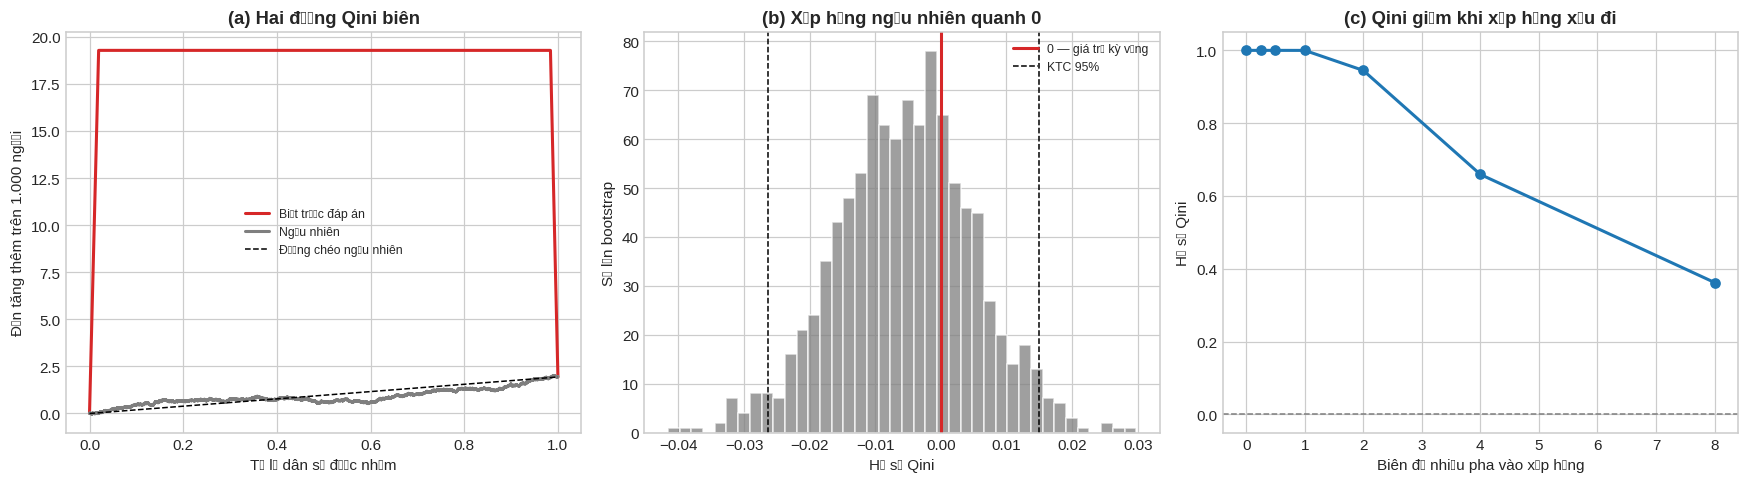

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) ba đường Qini
for s, nhan, mau in [(s_oracle, 'Biết trước đáp án', '#d62728'),
                     (score_ngau_nhien, 'Ngẫu nhiên', '#7f7f7f')]:
    x, g = qini_curve(y_sel, w_sel, s)
    axes[0].plot(x, g * 1000, label=nhan, color=mau, lw=2)
x, g = qini_curve(y_sel, w_sel, s_oracle)
axes[0].plot([0, 1], [0, g[-1] * 1000], '--', color='black', lw=1, label='Đường chéo ngẫu nhiên')
axes[0].set_xlabel('Tỉ lệ dân số được nhắm')
axes[0].set_ylabel('Đơn tăng thêm trên 1.000 người')
axes[0].set_title('(a) Hai đường Qini biên')
axes[0].legend(fontsize=8)

# (b) phân phối bootstrap của xếp hạng ngẫu nhiên
_, _, _, vals_rnd = bootstrap_ci(qini_score, y_sel, w_sel, score_ngau_nhien)
axes[1].hist(vals_rnd, bins=40, color='#7f7f7f', alpha=0.75, edgecolor='white')
axes[1].axvline(0, color='#d62728', lw=2, label='0 — giá trị kỳ vọng')
axes[1].axvline(lo_rnd, color='black', ls='--', lw=1)
axes[1].axvline(hi_rnd, color='black', ls='--', lw=1, label='KTC 95%')
axes[1].set_xlabel('Hệ số Qini')
axes[1].set_ylabel('Số lần bootstrap')
axes[1].set_title('(b) Xếp hạng ngẫu nhiên quanh 0')
axes[1].legend(fontsize=8)

# (c) suy giảm theo nhiễu
axes[2].plot(bang_nhieu['Biên độ nhiễu'], bang_nhieu['Qini'], 'o-', color='#1f77b4', lw=2)
axes[2].axhline(0, color='#7f7f7f', ls='--', lw=1)
axes[2].set_xlabel('Biên độ nhiễu pha vào xếp hạng')
axes[2].set_ylabel('Hệ số Qini')
axes[2].set_title('(c) Qini giảm khi xếp hạng xấu đi')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '14_kiem_chung_metric.png'), bbox_inches='tight')
plt.show()

### Bước 13 — Chốt cổng

Bốn phép thử phải đạt hết thì mới được đi tiếp. Dùng `assert` chứ không chỉ in ra màn hình, để nếu
sau này ai chạy lại notebook mà metric hỏng thì notebook dừng ngay tại đây thay vì tiếp tục sinh ra
một bảng benchmark sai.

In [17]:
kiem_chung = pd.DataFrame([
    {'Phép thử': '1. Xếp hạng ngẫu nhiên → Qini ≈ 0',
     'Kết quả': fmt_ci(q_rnd, lo_rnd, hi_rnd, 4), 'Đạt': chua_khong},
    {'Phép thử': '2. ATE khớp phép tính tay',
     'Kết quả': f'sai lệch {sai_lech:.1e}', 'Đạt': khop},
    {'Phép thử': '3. Biết trước ≫ ngẫu nhiên',
     'Kết quả': f'{dt_oracle/abs(dt_ngau_nhien):.0f} lần', 'Đạt': cao_hon},
    {'Phép thử': '4. Qini giảm đơn điệu theo nhiễu',
     'Kết quả': f'{bang_nhieu.Qini.iloc[0]:.3f} → {bang_nhieu.Qini.iloc[-1]:.3f}',
     'Đạt': giam_don_dieu},
])

display(kiem_chung)

assert kiem_chung['Đạt'].all(), 'Có phép kiểm chứng không đạt — sửa công thức metric trước khi đi tiếp'
print('\n✅ Bộ metric đã qua cả bốn phép kiểm chứng, dùng được cho các phần sau.')

,Phép thử,Kết quả,Đạt
0,1. Xếp hạng ngẫu nhiên → Qini ≈ 0,-0.0051 [-0.0264 – 0.0150],True
1,2. ATE khớp phép tính tay,sai lệch 0.0e+00,True
2,3. Biết trước ≫ ngẫu nhiên,196 lần,True
3,4. Qini giảm đơn điệu theo nhiễu,1.000 → 0.362,True



✅ Bộ metric đã qua cả bốn phép kiểm chứng, dùng được cho các phần sau.


---
# Phần 3 — RCT-holdout: chạy đúng một lần

> ## ⚠️ Điểm không quay lại
>
> Từ ô lệnh dưới đây trở đi, tập `rct_holdout` được mở ra. **Không được sửa mô hình, không được đổi
> siêu tham số, không được đổi bộ đặc trưng sau khi nhìn thấy những con số này.** Nếu lỡ làm vậy thì
> kết quả mất giá trị khoa học và cách duy nhất để cứu là chia lại dữ liệu từ notebook 02.
>
> Mọi quyết định đã chốt xong ở 04b và mã băm của bản khóa đã được kiểm ở Bước 3.
> Phần này chỉ đo và báo cáo — notebook này không có ô lệnh nào huấn luyện mô hình mới.

### Bước 14 — Nạp holdout và dự đoán

In [18]:
rct_hold = pd.read_parquet(os.path.join(DATA_DIR, 'rct_holdout.parquet'))
assert list(rct_hold.columns) == ['data_id', 'is_treat', 'label'] + FEATS

y_hold = rct_hold['label'].values
w_hold = rct_hold['is_treat'].values
X_hold = rct_hold[FEATS].values.astype(np.float32)

cate_hold = {name: nap_mo_hinh(name).predict_cate(X_hold) for name in OK_MODELS}

# Bản bàn giao: cùng mô hình quán quân nhưng huấn luyện trên đúng K_CHOT đặc trưng.
# Quyết định dùng bản nào đã khóa ở 04b, nên chấm điểm nó ở đây chỉ là đo, không phải chọn.
cate_hold_giao = MO_HINH_GIAO.predict_cate(X_hold[:, IDX_CHOT])

print(f'RCT-holdout: {len(rct_hold):,} dòng | treat {w_hold.mean()*100:.2f}% '
      f'| mua {y_hold.mean()*100:.2f}%')
print(f'Đã chấm điểm {len(cate_hold)} mô hình + bản bàn giao ({K_CHOT} đặc trưng)')

RCT-holdout: 90,835 dòng | treat 52.12% | mua 3.52%
Đã chấm điểm 6 mô hình + bản bàn giao (69 đặc trưng)


### Bước 15 — Bảng benchmark cuối

Đây là bảng chính của cả đề tài. Ba cột metric đầu đo khả năng xếp hạng; cột ATE là phép kiểm tra
xem mô hình có lệch hệ thống không; hai cột cuối là chi phí.

Cột `Dòng HL` phải đọc kèm: `CausalForestDML` học trên ít dữ liệu hơn hẳn nên **không so ngang hàng
được** với phần còn lại. Nếu nó xếp cuối thì chưa chắc do phương pháp kém.

In [19]:
ket_qua_hold = []
boot_hold = {}

for name in OK_MODELS:
    s = cate_hold[name]
    q, q_lo, q_hi, q_vals = bootstrap_ci(qini_score, y_hold, w_hold, s)
    a, a_lo, a_hi, _ = bootstrap_ci(auuc_score, y_hold, w_hold, s)
    boot_hold[name] = q_vals
    ket_qua_hold.append({
        'Mô hình': name,
        'Qini': q, 'Qini_lo': q_lo, 'Qini_hi': q_hi,
        'AUUC': a, 'AUUC_lo': a_lo, 'AUUC_hi': a_hi,
        'Uplift@10%': uplift_at_k(y_hold, w_hold, s, 0.1),
        'Uplift@20%': uplift_at_k(y_hold, w_hold, s, 0.2),
        'Uplift@30%': uplift_at_k(y_hold, w_hold, s, 0.3),
        'Giây': thoi_gian[name], 'Dòng HL': n_dong_fit[name],
    })

df_hold = pd.DataFrame(ket_qua_hold).sort_values('Qini', ascending=False).reset_index(drop=True)

ate_hold = ate_with_ci(y_hold, w_hold)

bang_cuoi = pd.DataFrame({
    'Mô hình': df_hold['Mô hình'],
    'Qini [KTC 95%]': [fmt_ci(r.Qini, r.Qini_lo, r.Qini_hi) for r in df_hold.itertuples()],
    'AUUC [KTC 95%]': [fmt_ci(r.AUUC, r.AUUC_lo, r.AUUC_hi) for r in df_hold.itertuples()],
    'Uplift@10%': (df_hold['Uplift@10%'] * 100).round(3).astype(str) + ' pp',
    'Uplift@20%': (df_hold['Uplift@20%'] * 100).round(3).astype(str) + ' pp',
    'Uplift@30%': (df_hold['Uplift@30%'] * 100).round(3).astype(str) + ' pp',
    'Dòng HL': df_hold['Dòng HL'].map('{:,}'.format),
    'Giây': df_hold['Giây'].round(1),
})

print(f'ATE toàn tập RCT-holdout: {ate_hold["ate"]*100:.3f} pp '
      f'[{ate_hold["ci_thap"]*100:.3f} – {ate_hold["ci_cao"]*100:.3f}]\n')
display(bang_cuoi)

ATE toàn tập RCT-holdout: 0.376 pp [0.137 – 0.615]



,Mô hình,Qini [KTC 95%],AUUC [KTC 95%],Uplift@10%,Uplift@20%,Uplift@30%,Dòng HL,Giây
0,CausalForestDML,0.030 [0.009 – 0.053],0.032 [0.009 – 0.057],1.748 pp,0.735 pp,0.624 pp,"926,669",1861.6
1,NonParamDML,0.028 [0.006 – 0.052],0.030 [0.006 – 0.056],1.724 pp,0.969 pp,0.735 pp,"926,669",86.0
2,TLearner,0.027 [0.001 – 0.052],0.029 [0.001 – 0.056],1.158 pp,0.981 pp,0.765 pp,"926,669",20.8
3,SLearner,0.026 [0.003 – 0.051],0.028 [0.004 – 0.055],1.354 pp,0.725 pp,0.834 pp,"926,669",11.0
4,LinearDML,0.024 [0.004 – 0.048],0.026 [0.005 – 0.052],0.879 pp,0.911 pp,0.809 pp,"926,669",171.7
5,DRLearner,0.016 [-0.008 – 0.042],0.017 [-0.009 – 0.046],0.845 pp,1.016 pp,0.713 pp,"926,669",213.6


### Bước 16 — Bản bàn giao trên holdout

Bảng trên là 6 mô hình học trên **toàn bộ 69 đặc trưng**. Bản thật sự được bàn giao là mô hình quán quân với `K_CHOT` đặc trưng đã chốt ở 04b — nếu `K_CHOT = 69` thì hai bản là một.

Ô lệnh dưới đo bản bàn giao trên cùng tập holdout, để con số trong `metadata.json` mô tả **đúng file được giao** chứ không phải một mô hình khác.

In [20]:
q_g, q_g_lo, q_g_hi, _ = bootstrap_ci(qini_score, y_hold, w_hold, cate_hold_giao)
a_g, a_g_lo, a_g_hi, _ = bootstrap_ci(auuc_score, y_hold, w_hold, cate_hold_giao)

metric_ban_giao = {
    'so_dac_trung': int(K_CHOT),
    'qini': float(q_g), 'qini_ci': [float(q_g_lo), float(q_g_hi)],
    'auuc': float(a_g), 'auuc_ci': [float(a_g_lo), float(a_g_hi)],
    'uplift_at_10': float(uplift_at_k(y_hold, w_hold, cate_hold_giao, 0.1)),
    'uplift_at_20': float(uplift_at_k(y_hold, w_hold, cate_hold_giao, 0.2)),
    'uplift_at_30': float(uplift_at_k(y_hold, w_hold, cate_hold_giao, 0.3)),
}

r_full = df_hold[df_hold['Mô hình'] == quan_quan].iloc[0]
display(pd.DataFrame([
    {'Bản': f'{quan_quan} — đầy đủ {N_FEAT} đặc trưng',
     'Qini [KTC 95%]': fmt_ci(r_full.Qini, r_full.Qini_lo, r_full.Qini_hi),
     'Uplift@20%': f'{r_full["Uplift@20%"]*100:.3f} pp'},
    {'Bản': f'{quan_quan} — bàn giao {K_CHOT} đặc trưng',
     'Qini [KTC 95%]': fmt_ci(q_g, q_g_lo, q_g_hi),
     'Uplift@20%': f'{metric_ban_giao["uplift_at_20"]*100:.3f} pp'},
]))

if K_CHOT == N_FEAT:
    print('K_CHOT = 69 nên hai dòng là cùng một mô hình — con số phải trùng khít.')
    assert abs(q_g - r_full.Qini) < 1e-12

,Bản,Qini [KTC 95%],Uplift@20%
0,DRLearner — đầy đủ 69 đặc trưng,0.016 [-0.008 – 0.042],1.016 pp
1,DRLearner — bàn giao 69 đặc trưng,0.016 [-0.008 – 0.042],1.016 pp


K_CHOT = 69 nên hai dòng là cùng một mô hình — con số phải trùng khít.


### Bước 17 — Đường Cumulative Gain của cả 6 mô hình

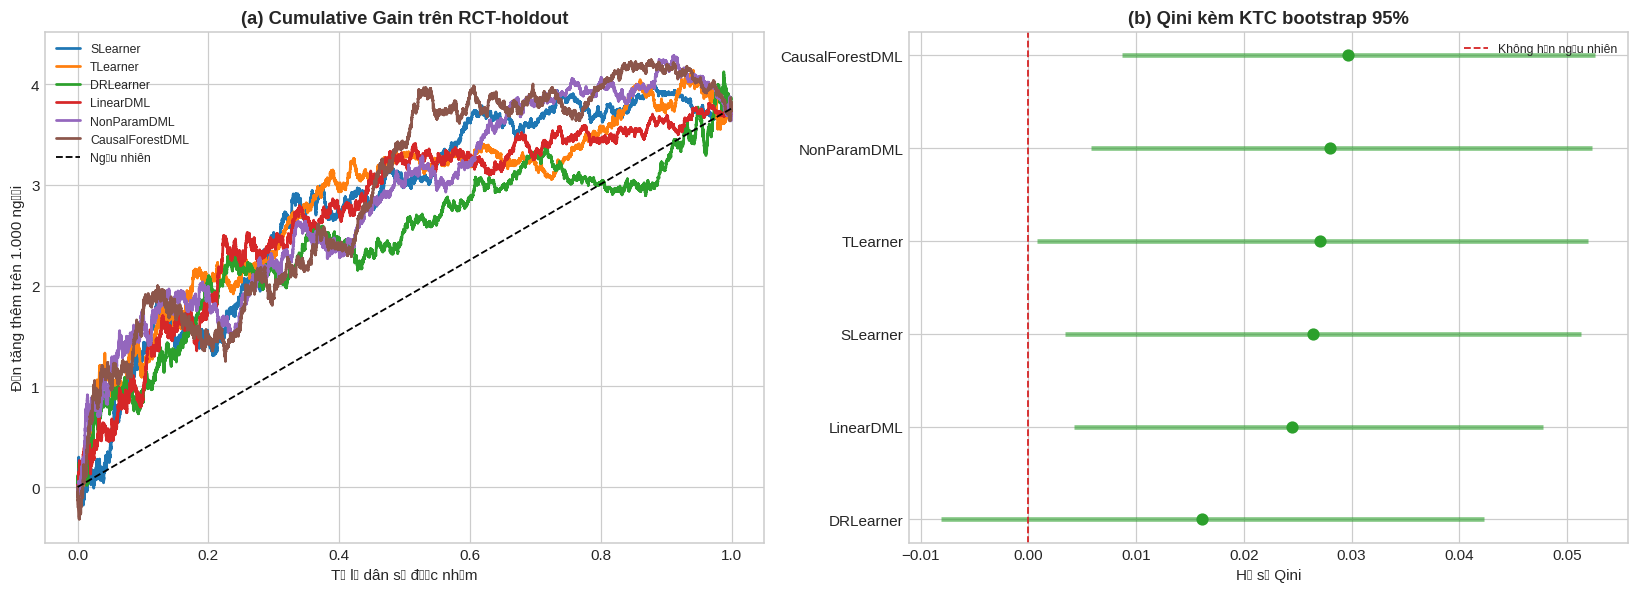

In [21]:
mau_sac = plt.cm.tab10(np.linspace(0, 1, 10))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

for i, name in enumerate(OK_MODELS):
    x, g = gain_curve(y_hold, w_hold, cate_hold[name])
    axes[0].plot(x, g * 1000, label=name, color=mau_sac[i], lw=1.8)

x, g = gain_curve(y_hold, w_hold, cate_hold[OK_MODELS[0]])
axes[0].plot([0, 1], [0, g[-1] * 1000], '--', color='black', lw=1.2, label='Ngẫu nhiên')
axes[0].set_xlabel('Tỉ lệ dân số được nhắm')
axes[0].set_ylabel('Đơn tăng thêm trên 1.000 người')
axes[0].set_title('(a) Cumulative Gain trên RCT-holdout')
axes[0].legend(fontsize=8, loc='upper left')

dfp = df_hold.iloc[::-1]
ypos = np.arange(len(dfp))
axes[1].hlines(ypos, dfp['Qini_lo'], dfp['Qini_hi'], color='#2ca02c', lw=3, alpha=0.6)
axes[1].plot(dfp['Qini'], ypos, 'o', color='#2ca02c', ms=7)
axes[1].axvline(0, color='#d62728', ls='--', lw=1.2, label='Không hơn ngẫu nhiên')
axes[1].set_yticks(ypos)
axes[1].set_yticklabels(dfp['Mô hình'])
axes[1].set_xlabel('Hệ số Qini')
axes[1].set_title('(b) Qini kèm KTC bootstrap 95%')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '17_benchmark_holdout.png'), bbox_inches='tight')
plt.show()

### Bước 18 — Kết quả trên RCT-select có tái lập được trên RCT-holdout không?

Một phép đối chiếu ít người làm nhưng rất đáng: nếu thứ hạng ở hai tập RCT khác hẳn nhau thì đó là
bằng chứng trực tiếp cho thấy chênh lệch giữa các mô hình chỉ là nhiễu, chứ không phải năng lực thật.

Đo bằng tương quan hạng Spearman giữa hai bảng xếp hạng.

In [22]:
df_sel = pd.DataFrame(select_meta['xep_hang_rct_select'])

doi_chieu = pd.merge(
    df_sel[['Mô hình', 'Qini']].rename(columns={'Qini': 'Qini trên select'}),
    df_hold[['Mô hình', 'Qini']].rename(columns={'Qini': 'Qini trên holdout'}),
    on='Mô hình')

rho, pval = stats.spearmanr(doi_chieu['Qini trên select'], doi_chieu['Qini trên holdout'])
doi_chieu['Hạng select'] = doi_chieu['Qini trên select'].rank(ascending=False).astype(int)
doi_chieu['Hạng holdout'] = doi_chieu['Qini trên holdout'].rank(ascending=False).astype(int)

display(doi_chieu.round(4))
print(f'\nTương quan hạng Spearman: {rho:+.3f} (p = {pval:.3f})')
if rho < 0.5:
    print('=> Thứ hạng KHÔNG tái lập được giữa hai tập RCT. Đây là bằng chứng độc lập')
    print('   cho thấy chênh lệch giữa các mô hình nằm trong vùng nhiễu.')
else:
    print('=> Thứ hạng tương đối ổn định giữa hai tập RCT.')

,Mô hình,Qini trên select,Qini trên holdout,Hạng select,Hạng holdout
0,DRLearner,0.0274,0.0161,1,6
1,SLearner,0.0186,0.0264,2,4
2,TLearner,0.0161,0.0270,3,3
3,CausalForestDML,0.0155,0.0297,4,1
4,NonParamDML,0.0146,0.0280,5,2
5,LinearDML,0.0066,0.0244,6,5



Tương quan hạng Spearman: -0.371 (p = 0.468)
=> Thứ hạng KHÔNG tái lập được giữa hai tập RCT. Đây là bằng chứng độc lập
   cho thấy chênh lệch giữa các mô hình nằm trong vùng nhiễu.


---
### Mô phỏng chính sách

Phần dịch kết quả sang ngôn ngữ nghiệp vụ. Hội đồng không đọc hệ số Qini, nhưng đọc được câu
*"cắt 70% ngân sách voucher mà vẫn giữ được ngần này phần trăm hiệu quả"*.

### Bước 19 — Hàm mô phỏng

So ba chính sách trên cùng tập `rct_holdout`:

| Chính sách | Cách làm |
|---|---|
| Phát đại trà | Mọi khách hàng đều nhận voucher |
| Nhắm mục tiêu | Chỉ k% có CATE dự đoán cao nhất |
| Không phát | Mốc dưới |

Vì đây là dữ liệu RCT nên có thể ước lượng trung thực: trong nhóm k% được chọn, so tỉ lệ mua của
những người *tình cờ* nhận voucher với những người *tình cờ* không nhận. Ngẫu nhiên hóa đảm bảo hai
nhóm con này so sánh được với nhau.

Con số ngân sách tiết kiệm giả định mỗi voucher tốn như nhau, nên tiết kiệm đúng bằng `1 − k`.

In [23]:
def policy_simulation(y, w, score, cac_muc=(0.1, 0.2, 0.3, 0.5, 1.0), seed=SEED):
    n = len(y)
    rng = np.random.RandomState(seed)
    order = np.lexsort((rng.rand(n), -np.asarray(score, dtype=float)))
    y, w = np.asarray(y), np.asarray(w)

    cvr_control_toan_tap = y[w == 0].mean()
    ate_toan_tap = ate_with_ci(y, w)['ate']
    don_neu_phat_dai_tra = ate_toan_tap * n

    rows = []
    for k in cac_muc:
        m = max(1, int(round(k * n)))
        top = order[:m]
        yt, wt = y[top], w[top]
        if wt.sum() == 0 or (1 - wt).sum() == 0:
            continue
        up = yt[wt == 1].mean() - yt[wt == 0].mean()
        don_them = up * m
        rows.append({
            'Nhắm k%': f'{k*100:.0f}%',
            'Số người nhận': m,
            'Uplift trong nhóm': up,
            'Đơn tăng thêm': don_them,
            '% hiệu quả giữ được': (don_them / don_neu_phat_dai_tra * 100
                                    if don_neu_phat_dai_tra else np.nan),
            'Voucher tiết kiệm': 1 - k,
            'CVR sau chiến dịch': cvr_control_toan_tap + don_them / n,
        })
    return pd.DataFrame(rows), cvr_control_toan_tap, don_neu_phat_dai_tra


print('Đã định nghĩa policy_simulation')

Đã định nghĩa policy_simulation


### Bước 20 — Mô phỏng cho mô hình quán quân

In [24]:
sim, cvr_nen, don_dai_tra = policy_simulation(y_hold, w_hold, cate_hold[quan_quan])

print(f'Mô hình         : {quan_quan}')
print(f'Tập             : rct_holdout ({len(rct_hold):,} người)')
print(f'CVR nền (không phát voucher): {cvr_nen*100:.3f}%')
print(f'Nếu phát đại trà: thêm {don_dai_tra:.0f} đơn, tốn {len(rct_hold):,} voucher\n')

hien_thi = sim.copy()
hien_thi['Uplift trong nhóm'] = (hien_thi['Uplift trong nhóm'] * 100).round(3).astype(str) + ' pp'
hien_thi['Đơn tăng thêm'] = hien_thi['Đơn tăng thêm'].round(0).astype(int)
hien_thi['% hiệu quả giữ được'] = hien_thi['% hiệu quả giữ được'].round(1)
hien_thi['Voucher tiết kiệm'] = (hien_thi['Voucher tiết kiệm'] * 100).round(0).astype(int).astype(str) + '%'
hien_thi['CVR sau chiến dịch'] = (hien_thi['CVR sau chiến dịch'] * 100).round(3).astype(str) + '%'
hien_thi['Số người nhận'] = hien_thi['Số người nhận'].map('{:,}'.format)
display(hien_thi)

Mô hình         : DRLearner
Tập             : rct_holdout (90,835 người)
CVR nền (không phát voucher): 3.325%
Nếu phát đại trà: thêm 342 đơn, tốn 90,835 voucher



,Nhắm k%,Số người nhận,Uplift trong nhóm,Đơn tăng thêm,% hiệu quả giữ được,Voucher tiết kiệm,CVR sau chiến dịch
0,10%,"9,084",0.845 pp,77,22.5,90%,3.409%
1,20%,"18,167",1.016 pp,185,54.0,80%,3.528%
2,30%,"27,250",0.713 pp,194,56.9,70%,3.539%
3,50%,"45,418",0.508 pp,231,67.5,50%,3.579%
4,100%,"90,835",0.376 pp,342,100.0,0%,3.701%


### Bước 21 — Biểu đồ mô phỏng chính sách

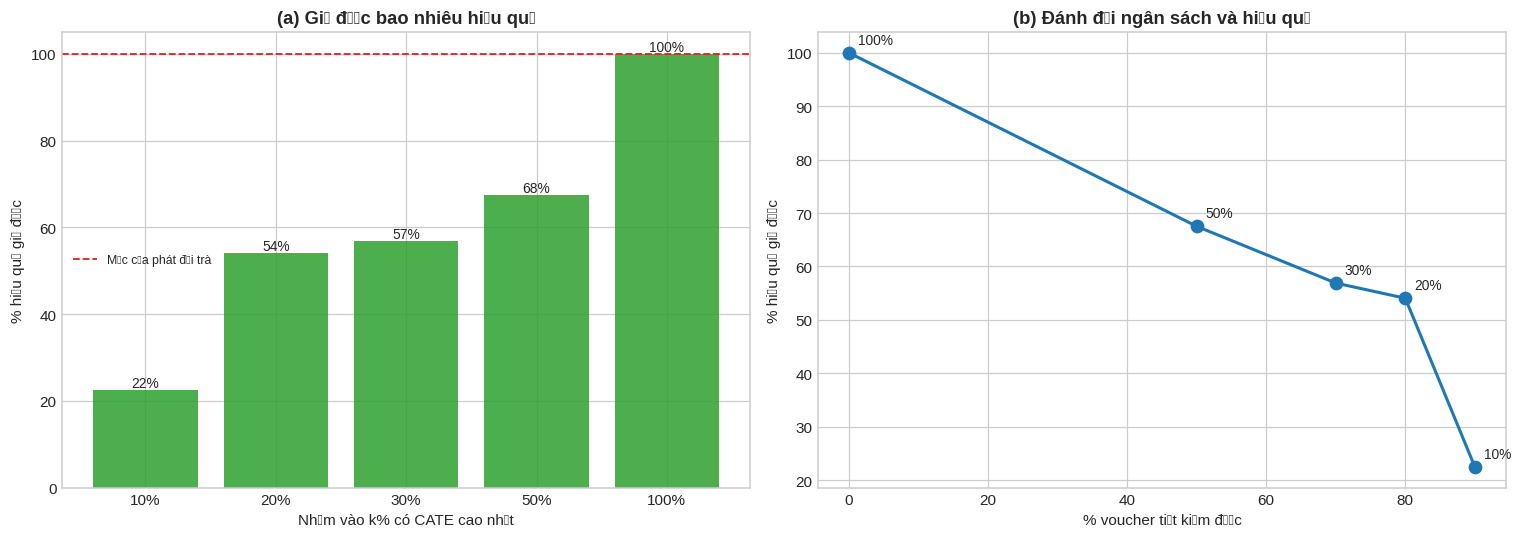

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x_lab = sim['Nhắm k%']
xp = np.arange(len(sim))

axes[0].bar(xp, sim['% hiệu quả giữ được'], color='#2ca02c', alpha=0.85)
axes[0].axhline(100, color='#d62728', ls='--', lw=1.2, label='Mức của phát đại trà')
axes[0].set_xticks(xp)
axes[0].set_xticklabels(x_lab)
axes[0].set_xlabel('Nhắm vào k% có CATE cao nhất')
axes[0].set_ylabel('% hiệu quả giữ được')
axes[0].set_title('(a) Giữ được bao nhiêu hiệu quả')
axes[0].legend(fontsize=8)
for i, v in enumerate(sim['% hiệu quả giữ được']):
    axes[0].text(i, v, f'{v:.0f}%', ha='center', va='bottom', fontsize=9)

axes[1].plot(sim['Voucher tiết kiệm'] * 100, sim['% hiệu quả giữ được'],
             'o-', color='#1f77b4', lw=2, ms=8)
for _, r in sim.iterrows():
    axes[1].annotate(r['Nhắm k%'], (r['Voucher tiết kiệm'] * 100, r['% hiệu quả giữ được']),
                     textcoords='offset points', xytext=(6, 6), fontsize=9)
axes[1].set_xlabel('% voucher tiết kiệm được')
axes[1].set_ylabel('% hiệu quả giữ được')
axes[1].set_title('(b) Đánh đổi ngân sách và hiệu quả')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '18_mo_phong_chinh_sach.png'), bbox_inches='tight')
plt.show()

---
### Phân tích nhóm Persuadables

Câu trả lời trực tiếp cho mục tiêu nghiệp vụ: tìm người **chỉ mua khi có voucher**, tránh đốt ngân
sách vào người vốn dĩ đã mua.

Phần này chỉ mô tả lại nhóm khách hàng dựa trên dự đoán đã có ở Bước 14 — không huấn luyện thêm mô
hình nào, nên không vi phạm nguyên tắc một lần của holdout.

### Bước 22 — Uplift thực đo của nhóm top 20% so với phần còn lại

Nếu mô hình có giá trị thì uplift thực đo ở nhóm top phải cao hơn hẳn nhóm còn lại. Cả hai con số
đều kèm khoảng tin cậy, vì mỗi nhóm chỉ có một phần của tập holdout nên sai số không nhỏ.

In [26]:
s_qq = cate_hold[quan_quan]
nguong = np.percentile(s_qq, 80)
la_top = s_qq >= nguong

nhom = []
for ten, mask in [('Top 20% (persuadables)', la_top), ('80% còn lại', ~la_top)]:
    r = ate_with_ci(y_hold[mask], w_hold[mask])
    nhom.append({'Nhóm': ten, 'Số người': int(mask.sum()),
                 'CATE dự đoán TB': s_qq[mask].mean(),
                 'Uplift thực đo': r['ate'],
                 'KTC 95%': f"[{r['ci_thap']*100:.3f} – {r['ci_cao']*100:.3f}] pp"})

df_nhom = pd.DataFrame(nhom)
df_nhom['CATE dự đoán TB'] = (df_nhom['CATE dự đoán TB'] * 100).round(3).astype(str) + ' pp'
df_nhom['Uplift thực đo'] = (df_nhom['Uplift thực đo'] * 100).round(3).astype(str) + ' pp'
display(df_nhom)

r_top = ate_with_ci(y_hold[la_top], w_hold[la_top])
r_rest = ate_with_ci(y_hold[~la_top], w_hold[~la_top])
d = r_top['ate'] - r_rest['ate']
se_d = np.sqrt(r_top['se']**2 + r_rest['se']**2)
print(f'\nChênh lệch top vs phần còn lại: {d*100:+.3f} pp ± {1.96*se_d*100:.3f} pp')
print(f'Khác 0 có ý nghĩa thống kê: {"CÓ" if abs(d) > 1.96*se_d else "KHÔNG"}')

,Nhóm,Số người,CATE dự đoán TB,Uplift thực đo,KTC 95%
0,Top 20% (persuadables),18167,2.617 pp,1.016 pp,[0.240 – 1.793] pp
1,80% còn lại,72668,0.16 pp,0.229 pp,[0.004 – 0.454] pp



Chênh lệch top vs phần còn lại: +0.787 pp ± 0.809 pp
Khác 0 có ý nghĩa thống kê: KHÔNG


### Bước 23 — Nhóm persuadables khác phần còn lại ở đặc trưng nào?

Dùng lại đúng công cụ SMD của notebook 01, lần này so hai nhóm chia theo CATE dự đoán thay vì chia
theo treatment. Đây là phần diễn giải được cho slide: *"nhóm đáng phát voucher là những người có
đặc điểm gì"*.

,SMD (top 20% − còn lại)
f28,0.975
f26,0.953
f9,0.843
f20,0.839
f16,0.827
f11,0.817
f35,0.794
f3,0.773
f14,0.754
f13,0.753


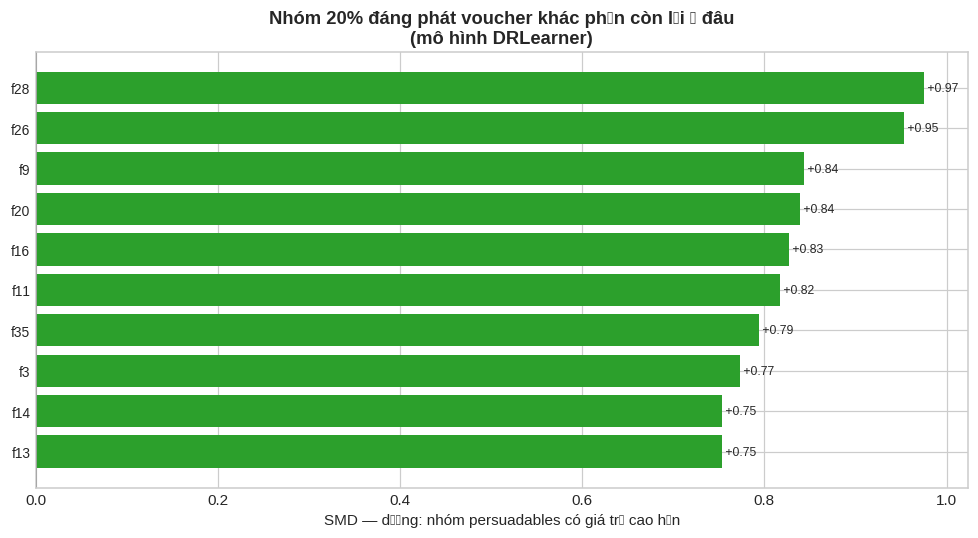

In [27]:
def compute_smd(a, b, cols):
    ma, mb = a[cols].mean(), b[cols].mean()
    sd = np.sqrt((a[cols].var() + b[cols].var()) / 2)
    return ((ma - mb) / sd.replace(0, np.nan)).dropna()

feat_xet = FEAT_CHOT   # bộ đặc trưng đã chốt ở 04b
smd_nhom = compute_smd(rct_hold[la_top], rct_hold[~la_top], feat_xet)
smd_nhom = smd_nhom.reindex(smd_nhom.abs().sort_values(ascending=False).index)

display(smd_nhom.head(10).to_frame('SMD (top 20% − còn lại)').round(3))

top10 = smd_nhom.head(10)[::-1]
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(range(len(top10)), top10.values,
        color=['#2ca02c' if v > 0 else '#d62728' for v in top10.values])
ax.axvline(0, color='black', lw=1)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10.index, fontsize=9)
ax.set_xlabel('SMD — dương: nhóm persuadables có giá trị cao hơn')
ax.set_title(f'Nhóm 20% đáng phát voucher khác phần còn lại ở đâu\n(mô hình {quan_quan})')
for i, v in enumerate(top10.values):
    ax.text(v, i, f' {v:+.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '19_phan_tich_persuadables.png'), bbox_inches='tight')
plt.show()

---
# Phần 5 — Bàn giao

### Bước 24 — Xuất mô hình

Mã băm bản khóa đã được kiểm ở Bước 3, trước cả khi holdout được mở. Ô lệnh này kiểm **lần nữa** ngay trước khi ghi file — vì giữa hai thời điểm đó có cả Phần 3 và Phần 4, tức là toàn bộ phần một người có thể nhìn thấy kết quả rồi đổi ý.

`model.pkl` là đúng file `04b_model_ban_giao.pkl` mà 04b đã ghi, chép sang tên chuẩn — không phải một bản dựng lại. Chép nguyên byte thì không có chỗ nào để lệch.

In [28]:
goi_lai = {k: v for k, v in khoa.items() if k not in ('thoi_diem_khoa', 'ma_bam')}
hash_lai = hashlib.sha256(
    json.dumps(goi_lai, ensure_ascii=False, sort_keys=True).encode('utf-8')).hexdigest()[:16]
assert hash_lai == KHOA_HASH, (
    'Quyết định đã đổi sau khi mở holdout. Kết quả ở Phần 3 không còn giá trị khoa học — '
    'cách duy nhất để cứu là chạy lại từ 04b.')
print(f'🔒 Mã băm quyết định vẫn khớp bản khóa của 04b: {KHOA_HASH}\n')

model_path = os.path.join(ART_DIR, 'model.pkl')
nguon_pkl = tim_file('04b_model_ban_giao.pkl')
if os.path.abspath(nguon_pkl) != os.path.abspath(model_path):
    shutil.copyfile(nguon_pkl, model_path)

print(f'{model_path} — {quan_quan}, {K_CHOT} đặc trưng, '
      f'{os.path.getsize(model_path)/1e6:.2f} MB')
print(f'  nguồn: {nguon_pkl}')
print(f'  cách dựng: {select_meta["nguon_mo_hinh_ban_giao"]}')

full_path = None
if K_CHOT < N_FEAT:
    full_path = os.path.join(ART_DIR, 'model_full.pkl')
    with open(full_path, 'wb') as f:
        cloudpickle.dump(nap_mo_hinh(quan_quan), f)
    print(f'{full_path} — bản đầy đủ {N_FEAT} đặc trưng (bản trong bảng benchmark)')
else:
    print(f'k chốt = {N_FEAT} nên bản bàn giao chính là bản benchmark đầy đủ '
          '— không sinh model_full.pkl để khỏi có hai file giống hệt nhau.')

🔒 Mã băm quyết định vẫn khớp bản khóa của 04b: 3960fbe51566cb1a

/kaggle/working/artifacts/model.pkl — DRLearner, 69 đặc trưng, 0.44 MB
  nguồn: /kaggle/input/notebooks/hatrungkienhatuki/lazada-04b-select/artifacts/04b_model_ban_giao.pkl
  cách dựng: mô hình của 04a (926,669 dòng, toàn bộ đặc trưng)
k chốt = 69 nên bản bàn giao chính là bản benchmark đầy đủ — không sinh model_full.pkl để khỏi có hai file giống hệt nhau.


### Bước 25 — Bản mô hình không phụ thuộc phiên bản Python

`model.pkl` dùng `cloudpickle`, mà `cloudpickle` đóng gói class kèm cả **code object** — và cấu trúc
code object **không tương thích giữa các bản Python**. Hệ quả rất cụ thể: file đóng gói bằng Python
3.12 sẽ không nạp được bằng môi trường khóa của dự án (3.10.9), báo
`TypeError: code expected at most 16 arguments, got 18`.

Cách chặn tận gốc: xuất thêm cây LightGBM ra **định dạng text gốc của thư viện**. Định dạng này không
chứa code Python nào, nên đọc được bằng mọi bản Python và cả ngôn ngữ khác.

Số booster và số cột đầu vào phụ thuộc cấu trúc của mô hình quán quân, nên phải ghi rõ vào metadata
thay vì để DE tự đoán:

| Quán quân | File | Số cột đầu vào | Ghép CATE thế nào |
|---|---|---|---|
| DR-Learner | `model_booster.txt` | `K_CHOT` | `booster.predict(X)` |
| S-Learner | `model_booster.txt` | `K_CHOT + 1` | `p(X,1) − p(X,0)`, cột cuối là `is_treat` |
| T-Learner | `model_booster.txt` + `model_booster_control.txt` | `K_CHOT` mỗi bản | `p1(X) − p0(X)` |
| LinearDML / NonParamDML / CausalForestDML | — | — | không có dạng text; chỉ bàn giao được `model.pkl` |

Ô lệnh có `assert` đối chiếu dự đoán của hai bản: chúng phải **trùng khít tuyệt đối**, không phải xấp
xỉ. Lệch dù một chữ số nghĩa là bản text không dùng thay được.

In [29]:
def lay_booster(m, ten):
    '''Các booster LightGBM của mô hình bàn giao, kèm số cột đầu vào mà mỗi bản chờ đợi.'''
    if ten == 'DRLearner':
        return [('model_booster.txt', m.model.booster_, K_CHOT,
                 'LGBMRegressor tầng cuối — đầu vào đúng các cột trong feature_contract.json, '
                 'đầu ra là CATE')]
    if ten == 'SLearner':
        return [('model_booster.txt', m.model.booster_, K_CHOT + 1,
                 'LGBMClassifier trên [X, is_treat] — CATE = p(X,1) − p(X,0); cột cuối là is_treat')]
    if ten == 'TLearner':
        return [('model_booster.txt', m.m1.booster_, K_CHOT, 'nhánh treatment — p1(X)'),
                ('model_booster_control.txt', m.m0.booster_, K_CHOT, 'nhánh control — p0(X)')]
    return []


def cate_tu_booster(bs, X, ten):
    '''Ghép CATE từ booster dạng text — đúng cách AI Service sẽ làm nếu không dùng model.pkl.'''
    if ten == 'DRLearner':
        return bs[0].predict(X)
    if ten == 'SLearner':
        n = len(X)
        return (bs[0].predict(np.column_stack([X, np.ones(n)]))
                - bs[0].predict(np.column_stack([X, np.zeros(n)])))
    if ten == 'TLearner':
        return bs[0].predict(X) - bs[1].predict(X)
    raise ValueError(f'{ten} không có dạng booster text')


X_GIAO_HOLD = X_hold[:, IDX_CHOT]
mo_ta_booster = lay_booster(MO_HINH_GIAO, quan_quan)

if mo_ta_booster:
    bs, thong_tin = [], []
    for ten_file, booster, so_cot_cho, mo_ta in mo_ta_booster:
        p = os.path.join(ART_DIR, ten_file)
        booster.save_model(p)
        lai = lgb.Booster(model_file=p)
        assert lai.num_feature() == so_cot_cho, (
            f'{ten_file} nhận {lai.num_feature()} cột nhưng cấu trúc {quan_quan} '
            f'đòi {so_cot_cho} (contract có {K_CHOT} cột)')
        bs.append(lai)
        thong_tin.append({'file': ten_file, 'so_cot_dau_vao': int(lai.num_feature()),
                          'so_cay': int(lai.num_trees()), 'mo_ta': mo_ta})
        print(f'{p} — {lai.num_feature()} cột đầu vào, {lai.num_trees()} cây, '
              f'{os.path.getsize(p)/1e6:.2f} MB')

    X_kiem = X_GIAO_HOLD[:3000]
    lech_booster = float(np.abs(cate_tu_booster(bs, X_kiem, quan_quan)
                                - MO_HINH_GIAO.predict_cate(X_kiem)).max())
    assert lech_booster == 0.0, \
        f'Bản text lệch {lech_booster:.3e} so với model.pkl — không dùng thay được'

    BOOSTER_INFO = {
        'files': thong_tin,
        'so_cot_contract': int(K_CHOT),
        'cot_bo_sung': ['is_treat'] if quan_quan == 'SLearner' else [],
        'cach_ghep_cate': {'DRLearner': 'booster.predict(X)',
                           'SLearner': 'booster.predict([X,1]) - booster.predict([X,0])',
                           'TLearner': 'treat.predict(X) - control.predict(X)'}[quan_quan],
        'lech_so_voi_model_pkl': lech_booster,
    }
    print(f'\nĐối chiếu 3.000 dự đoán với model.pkl: lệch {lech_booster:.3e}  ->  trùng khít')
else:
    BOOSTER_INFO = None
    print(f'⚠️  {quan_quan} là estimator EconML, không có dạng text của LightGBM.')
    print('    Bản bàn giao chỉ có model.pkl, và nó phụ thuộc phiên bản Python — ghi rõ trong metadata.')

/kaggle/working/artifacts/model_booster.txt — 69 cột đầu vào, 200 cây, 0.43 MB

Đối chiếu 3.000 dự đoán với model.pkl: lệch 0.000e+00  ->  trùng khít


### Bước 26 — Feature Contract cho DE

Contract liệt kê **đúng những cột mô hình nhận vào**, không hơn không kém: `K_CHOT` mục, mỗi mục một
cột gốc `f*`. Không có mục `fe_*` nào vì pipeline này không tạo đặc trưng dẫn xuất, nên AI Service
không phải tính lại công thức nào lúc phục vụ — một chỗ có thể lệch giữa huấn luyện và triển khai đã
được bỏ đi.

Bốn trường bắt buộc mỗi mục:

- **`thu_tu_dua_vao_mo_hinh`** — vị trí cột khi gọi `predict`. Sai thứ tự là sai dự đoán mà **không
  báo lỗi**, loại lỗi khó tìm nhất khi lên production.
- **`gia_tri_mac_dinh`** — trung vị trên Train + Val, dùng cho khách hàng mới chưa có dữ liệu trong
  feature store. Đây là giá trị dự phòng, **không phải** lời mời bỏ bớt cột: mọi cột trong contract
  đều phải lấy từ feature store ở đường chạy bình thường.
- **`khoang`** — biên giá trị quan sát được lúc huấn luyện, để DE dựng cảnh báo khi dữ liệu trôi.
- **`hang_permutation` / `hang_gain`** — thứ hạng quan trọng theo hai cách đo ở 04b,
  để DE biết cột nào đáng ưu tiên khi tối ưu chi phí feature store.

Dữ liệu ẩn danh hoàn toàn (`f0`…`f82`) nên không suy ra được cột nào tính online, cột nào tính offline
theo cửa sổ 7/30 ngày. Trường `tinh_online` để `null` kèm ghi chú thay vì đoán bừa.

In [30]:
hang_perm = select_meta['permutation_importance']['hang']
hang_gain = select_meta['gain_importance']['hang']

muc = []
for vi_tri, f in enumerate(FEAT_CHOT):
    col = full[f]
    muc.append({
        'ten': f,
        'thu_tu_dua_vao_mo_hinh': vi_tri,
        'nguon': 'goc',
        'kieu': 'nhi_phan' if col.nunique() == 2 else 'lien_tuc',
        'gia_tri_mac_dinh': float(col.median()),
        'khoang': [float(col.min()), float(col.max())],
        'hang_permutation': hang_perm.get(f),
        'hang_gain': hang_gain.get(f),
        'tinh_online': None,
    })

contract = {
    'phien_ban': datetime.now().strftime('%Y%m%d'),
    'mo_hinh': quan_quan,
    'file_mo_hinh': 'model.pkl',
    'file_khong_phu_thuoc_python': ([t['file'] for t in BOOSTER_INFO['files']]
                                    if BOOSTER_INFO else []),
    'so_cot_mo_hinh_nhan_vao': len(muc),
    'nguon_dac_trung': ('Toàn bộ lấy từ feature store. Pipeline này không có đặc trưng dẫn xuất '
                        'nên AI Service không phải tính công thức nào lúc phục vụ.'),
    'cach_dung': (f'Dựng vector đủ {len(muc)} cột theo thu_tu_dua_vao_mo_hinh rồi gọi '
                  f'model.predict_cate(X). Cột thiếu dữ liệu thì điền gia_tri_mac_dinh.'),
    'canh_bao_thu_tu': ('Sai thứ tự cột sẽ cho dự đoán sai mà KHÔNG báo lỗi. '
                        'Luôn dựng vector theo thu_tu_dua_vao_mo_hinh.'),
    'cach_chon_so_dac_trung': {
        'ket_qua': f'{len(muc)}/{N_FEAT}',
        'ly_do': ly_do,
        'cach_do': ('mỗi mức k huấn luyện lại mô hình quán quân trên đúng k đặc trưng đó, '
                    'rồi đo hệ số Qini trên rct_select kèm KTC bootstrap'),
        'tieu_chi': ['KTC Qini không chứa 0',
                     'đúng ở mọi k lớn hơn (tính bền)',
                     'KTC hiệu so với bản đầy đủ chứa 0'],
        'tap_dung_de_chot': 'rct_select',
        'thu_tu_bo_cot': 'permutation importance đo trên rct_select (04b)',
    },
    'gia_tri_mac_dinh_lay_tu': 'trung vị trên train + val',
    'gia_tri_mac_dinh_dung_khi_nao': 'khách hàng mới chưa có dữ liệu trong feature store',
    'ghi_chu_online_offline': ('Dữ liệu đã ẩn danh nên chưa xác định được đặc trưng nào tính online, '
                               'đặc trưng nào tính offline theo cửa sổ 7/30 ngày. '
                               'DE điền trường tinh_online sau khi đối chiếu bảng gốc.'),
    'golden_predictions': 'golden_predictions.csv — xem Bước 27',
    'dac_trung': muc,
}

# --- chốt cổng: contract, mô hình và booster phải nói về cùng một tập cột ---
assert [m['ten'] for m in muc] == FEAT_CHOT
assert [m['thu_tu_dua_vao_mo_hinh'] for m in muc] == list(range(len(muc)))
assert not any(m['ten'].startswith('fe_') for m in muc), 'Contract không được chứa cột fe_*'
assert contract['so_cot_mo_hinh_nhan_vao'] == K_CHOT
if BOOSTER_INFO:
    cot_bo_sung = len(BOOSTER_INFO['cot_bo_sung'])
    for t in BOOSTER_INFO['files']:
        assert t['so_cot_dau_vao'] == len(muc) + cot_bo_sung, \
            f"{t['file']}: {t['so_cot_dau_vao']} cột vs contract {len(muc)} (+{cot_bo_sung})"

contract_path = os.path.join(ART_DIR, 'feature_contract.json')
with open(contract_path, 'w', encoding='utf-8') as f:
    json.dump(contract, f, ensure_ascii=False, indent=2)

print(f'Đã ghi {contract_path}')
print(f'  Mô hình nhận vào : {len(muc)} cột, toàn bộ là cột gốc f*')
print(f'  Cột dẫn xuất fe_*: 0')
if BOOSTER_INFO:
    print(f'  Booster          : ' + ', '.join(
        f"{t['file']} ({t['so_cot_dau_vao']} cột)" for t in BOOSTER_INFO['files']))
display(pd.DataFrame(muc)[['thu_tu_dua_vao_mo_hinh', 'ten', 'kieu',
                           'gia_tri_mac_dinh', 'hang_permutation', 'hang_gain']].head(10))

Đã ghi /kaggle/working/artifacts/feature_contract.json
  Mô hình nhận vào : 69 cột, toàn bộ là cột gốc f*
  Cột dẫn xuất fe_*: 0
  Booster          : model_booster.txt (69 cột)


,thu_tu_dua_vao_mo_hinh,ten,kieu,gia_tri_mac_dinh,hang_permutation,hang_gain
0,0,f0,lien_tuc,2.000000,8,40
1,1,f1,lien_tuc,172.000000,13,6
2,2,f2,lien_tuc,166.000000,19,3
3,3,f3,lien_tuc,1.098612,12,29
4,4,f4,lien_tuc,1.500000,27,22
5,5,f5,lien_tuc,0.000000,24,8
6,6,f6,lien_tuc,0.000000,60,11
7,7,f7,lien_tuc,2.000000,46,50
8,8,f8,lien_tuc,1.000000,22,7
9,9,f9,lien_tuc,2.028148,18,28


### Bước 27 — Golden predictions

Một file nhỏ nhưng là thứ duy nhất cho phép phía DE **tự kiểm chứng** rằng service họ dựng chạy đúng
như mô hình lúc bàn giao: 1.000 dòng lấy từ `rct_select`, mỗi dòng gồm `data_id` và giá trị CATE mà
`model.pkl` cho ra.

Cách dùng phía DE: lấy `data_id`, dựng vector đặc trưng theo contract, gọi `predict`, rồi so với cột
`cate`. Chênh lệch phải bằng **0 tuyệt đối**. Khác 0 nghĩa là có gì đó lệch — sai thứ tự cột, sai kiểu
dữ liệu, sai phiên bản LightGBM — và bắt được ngay ở khâu tích hợp thay vì sau khi đã chạy chiến dịch.

Chọn từ `rct_select` chứ không phải `rct_holdout`: file này sẽ được dùng đi dùng lại nhiều lần trong
CI của phía DE, không nên phát tán nhãn của tập holdout.

Ghi bằng `float_format='%.17g'` để số `float64` đi qua vòng CSV mà không mất một bit nào — ô lệnh đọc
lại và `assert` đúng điều đó.

In [31]:
GOLDEN_N = 1_000

# Dung sai cho phép khi phía DE đối chiếu lại. Mô hình LightGBM dự đoán tất định tới
# từng bit nên đòi bằng 0 tuyệt đối. Estimator EconML giải một hệ tuyến tính cục bộ ở
# mỗi điểm, BLAS có thể đổi thứ tự phép cộng tuỳ cách mảng đầu vào nằm trong bộ nhớ,
# nên bitwise không bảo đảm — 1e-12 vẫn thấp hơn thang CATE (cỡ 1e-2) mười bậc.
TOL_PARITY = 0.0 if quan_quan in ('SLearner', 'TLearner', 'DRLearner') else 1e-12

# Sắp theo data_id để tập golden không phụ thuộc thứ tự dòng trong file parquet
thu_tu = np.argsort(rct_sel['data_id'].astype(str).values, kind='stable')[:GOLDEN_N]
X_golden = X_sel[np.ix_(thu_tu, IDX_CHOT)]
cate_golden = np.asarray(MO_HINH_GIAO.predict_cate(X_golden), dtype=np.float64)

golden = pd.DataFrame({'data_id': rct_sel['data_id'].values[thu_tu], 'cate': cate_golden})
golden_path = os.path.join(ART_DIR, 'golden_predictions.csv')
golden.to_csv(golden_path, index=False, float_format='%.17g')

# Đọc lại ngay: CSV phải round-trip float64 không mất bit nào.
# float_precision='round_trip' là bắt buộc — bộ phân tích mặc định của pandas nhanh hơn
# nhưng có thể lệch 1 ULP, đủ để phá phép so bằng tuyệt đối ở Bước 29.
golden_lai = pd.read_csv(golden_path, float_precision='round_trip')
assert np.array_equal(golden_lai['cate'].values, cate_golden), \
    'File CSV không tái lập đúng giá trị float64'

GOLDEN_HASH = hashlib.sha256(open(golden_path, 'rb').read()).hexdigest()[:16]

print(f'Đã ghi {golden_path}')
print(f'  {len(golden):,} dòng từ rct_select | mã băm {GOLDEN_HASH}')
print("  Đọc lại bằng pd.read_csv(..., float_precision='round_trip') -> khớp từng bit")
print(f'  CATE: trung bình {cate_golden.mean():+.6f} | '
      f'nhỏ nhất {cate_golden.min():+.6f} | lớn nhất {cate_golden.max():+.6f}')
print(f'  Dung sai khi đối chiếu lại: {TOL_PARITY:g}'
      + ('  (LightGBM tất định tới từng bit)' if TOL_PARITY == 0
         else '  (EconML: BLAS có thể đổi thứ tự phép cộng)'))
display(golden.head(5))

Đã ghi /kaggle/working/artifacts/golden_predictions.csv
  1,000 dòng từ rct_select | mã băm 1c3c933e7adfcdc1
  Đọc lại bằng pd.read_csv(..., float_precision='round_trip') -> khớp từng bit
  CATE: trung bình +0.005880 | nhỏ nhất -0.301436 | lớn nhất +0.401176
  Dung sai khi đối chiếu lại: 0  (LightGBM tất định tới từng bit)


,data_id,cate
0,test_0,0.001852
1,test_1,-0.022928
2,test_100,0.006734
3,test_10000,0.005241
4,test_100002,0.003402


### Bước 28 — `metadata.json`

Ghi đủ để tái lập và để đọc hiểu bản bàn giao mà không phải mở lại notebook: tên mô hình, siêu tham số,
**danh sách đặc trưng đúng thứ tự**, bảng quét k, hai bảng độ quan trọng, mã băm bản khóa quyết định,
metric trên holdout của cả 6 mô hình lẫn riêng bản bàn giao, và thông tin đóng gói.

In [32]:
import sys

metadata = {
    'ten_mo_hinh': quan_quan,
    'ngay_dong_goi': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'run_mode': RUN_MODE,
    'seed': SEED,
    'sieu_tham_so': select_meta['sieu_tham_so'],

    'chuoi_notebook': {
        '04a_run_id': train_meta['run_id'],
        '04b_run_id': select_meta['run_id_04b'],
        'run_mode': {'04a': train_meta['run_mode'], '04b': select_meta['run_mode'],
                     '04c': RUN_MODE},
        'nguon_tham_so_notebook_03': train_meta['nguon_tham_so'],
    },

    'dac_trung': FEAT_CHOT,
    'so_dac_trung': int(K_CHOT),
    'dac_trung_day_du': FEATS,
    'so_dac_trung_day_du': int(N_FEAT),
    'khong_co_dac_trung_dan_xuat': True,

    'quyet_dinh_da_khoa': {'file': 'decisions_locked.json', 'ma_bam': KHOA_HASH},
    'chon_so_dac_trung': select_meta['vong_quet_k'] | {
        'k_chot': int(K_CHOT), 'ly_do': ly_do, 'tap_dung_de_chot': 'rct_select'},
    'do_quan_trong_dac_trung': {
        'permutation': {k: v for k, v in select_meta['permutation_importance'].items()
                        if k != 'hang'},
        'gain': {k: v for k, v in select_meta['gain_importance'].items() if k != 'hang'},
        'tuong_quan_hang_gain_vs_permutation':
            select_meta['tuong_quan_hang_gain_vs_permutation'],
    },

    'file_ban_giao': {
        'model.pkl': f'{quan_quan} trên {K_CHOT} đặc trưng — bản khớp feature_contract.json',
        'model_full.pkl': (f'{quan_quan} trên {N_FEAT} đặc trưng — bản trong bảng benchmark'
                           if full_path else 'không sinh (k chốt = toàn bộ đặc trưng)'),
        'feature_contract.json': f'{K_CHOT} cột, đúng thứ tự đưa vào mô hình',
        'golden_predictions.csv': f'{GOLDEN_N} dự đoán mẫu để DE đối chiếu',
        'decisions_locked.json': 'quyết định đã khóa ở 04b, trước khi holdout được mở',
        **({t['file']: t['mo_ta'] for t in BOOSTER_INFO['files']} if BOOSTER_INFO else {}),
    },
    'booster': BOOSTER_INFO,
    'golden_predictions': {
        'file': 'golden_predictions.csv',
        'nguon': 'rct_select, 1.000 data_id nhỏ nhất theo thứ tự chuỗi',
        'so_dong': int(GOLDEN_N),
        'ma_bam': GOLDEN_HASH,
        'dung_sai': TOL_PARITY,
        'cach_kiem': ('dựng vector theo feature_contract.json cho từng data_id, gọi predict_cate, '
                      'so với cột cate — chênh lệch phải nằm trong dung_sai'),
    },
    'serialization': {
        'writer': f'cloudpickle=={cloudpickle.__version__}',
        'reader': 'pickle.load',
        'python_dong_goi': sys.version.split()[0],
        'python_yeu_cau_khi_nap': ('phải khớp python_dong_goi — cloudpickle không tương thích '
                                   'chéo bản Python'),
        'ban_khong_phu_thuoc_python': ([t['file'] for t in BOOSTER_INFO['files']]
                                       if BOOSTER_INFO else None),
    },
    'du_lieu_huan_luyen': {
        'nguon': 'train.parquet + val.parquet',
        'so_dong_quan_quan': int(select_meta['so_dong_huan_luyen_quan_quan']),
        'so_dong_moi_mo_hinh': {m: int(n_dong_fit[m]) for m in OK_MODELS},
        'cung_co_mau': bool(train_meta['cung_co_mau']),
        'cach_dung_ban_giao': select_meta['nguon_mo_hinh_ban_giao'],
        'giay_huan_luyen_ban_giao': select_meta['giay_huan_luyen_ban_giao'],
    },

    'metric_rct_select': {
        'xep_hang': select_meta['xep_hang_rct_select'],
        'so_sanh_theo_cap': select_meta['so_sanh_theo_cap'],
        'moc_ngau_nhien': select_meta['moc_ngau_nhien_tren_select'],
        'qini_ban_giao': select_meta['qini_ban_giao_tren_select'],
    },
    'metric_rct_holdout': {
        r['Mô hình']: {
            'qini': round(r['Qini'], 5), 'qini_ci': [round(r['Qini_lo'], 5), round(r['Qini_hi'], 5)],
            'auuc': round(r['AUUC'], 5), 'auuc_ci': [round(r['AUUC_lo'], 5), round(r['AUUC_hi'], 5)],
            'uplift_at_10': round(r['Uplift@10%'], 6),
            'uplift_at_20': round(r['Uplift@20%'], 6),
            'uplift_at_30': round(r['Uplift@30%'], 6),
        } for _, r in df_hold.iterrows()
    },
    'metric_ban_giao_rct_holdout': metric_ban_giao,
    'ate_rct_holdout': ate_hold,
    'chon_quan_quan': {
        'tap_dung': 'rct_select',
        'so_doi_thu_bi_vuot_co_y_nghia': int(select_meta['so_doi_thu_bi_vuot_co_y_nghia']),
        'tong_doi_thu': len(select_meta['so_sanh_theo_cap']),
        'tuong_quan_hang_select_vs_holdout': round(float(rho), 4),
    },
    'kiem_chung_metric': {
        '04b': select_meta['kiem_chung_metric'],
        '04c': {r['Phép thử']: bool(r['Đạt']) for _, r in kiem_chung.iterrows()},
    },
    'n_bootstrap': int(N_BOOT),
    'ghi_chu': ('Số đặc trưng bàn giao chốt trên rct_select — chính tập đã dùng để chọn — nên '
                'con số Qini của nó ở đó lạc quan hơn thực tế; metric_ban_giao_rct_holdout mới '
                'là con số đo trên tập chưa từng nhìn. Nếu cung_co_mau = false thì bảng '
                'benchmark trộn chất lượng phương pháp với lượng dữ liệu.'),
}

assert metadata['so_dac_trung'] == len(metadata['dac_trung']) == K_CHOT
assert not any(c.startswith('fe_') for c in metadata['dac_trung'])

meta_path = os.path.join(ART_DIR, 'metadata.json')
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

print(f'Đã ghi {meta_path}')
print(f'  mô hình {quan_quan} | {K_CHOT} đặc trưng | run_mode = {RUN_MODE}')
print(f'  Python đóng gói: {sys.version.split()[0]}')

Đã ghi /kaggle/working/artifacts/metadata.json
  mô hình DRLearner | 69 đặc trưng | run_mode = full
  Python đóng gói: 3.12.13


### Bước 29 — Nghiệm thu bản bàn giao

Ghi xong chưa phải là xong. Nạp lại **từ đĩa** rồi kiểm bốn thứ, tất cả đều đòi trùng khít tuyệt đối
chứ không xấp xỉ:

1. `model.pkl` nạp lại cho đúng dự đoán như mô hình trong bộ nhớ.
2. Contract và metadata mô tả **cùng một** danh sách đặc trưng, cùng thứ tự.
3. Dựng vector theo đúng contract cho các dòng golden rồi dự đoán — phải khớp từng chữ số với
   `golden_predictions.csv`. Đây chính là phép mà phía DE sẽ chạy.
4. Booster dạng text cho đúng kết quả như `model.pkl` trên chính các dòng golden đó.

In [33]:
with open(model_path, 'rb') as f:
    m_lai = pickle.load(f)
with open(meta_path, encoding='utf-8') as f:
    meta_lai = json.load(f)
with open(contract_path, encoding='utf-8') as f:
    ct_lai = json.load(f)
golden_lai = pd.read_csv(golden_path, float_precision='round_trip')

ten_ct = [d['ten'] for d in sorted(ct_lai['dac_trung'],
                                   key=lambda d: d['thu_tu_dua_vao_mo_hinh'])]

# [2] contract và metadata phải khớp nhau và khớp mô hình
assert ten_ct == meta_lai['dac_trung'] == FEAT_CHOT, 'contract lệch metadata'
assert ct_lai['so_cot_mo_hinh_nhan_vao'] == meta_lai['so_dac_trung'] == len(ten_ct)
assert not any(t.startswith('fe_') for t in ten_ct)

# [1] mô hình xuất ra đĩa có nguyên vẹn không
lech_export = float(np.abs(m_lai.predict_cate(rct_hold[ten_ct].values.astype(np.float32))
                           - cate_hold_giao).max())
assert lech_export < 1e-12, f'Mô hình nạp lại cho dự đoán khác ({lech_export:.2e})'

# [3] golden predictions — đúng phép mà DE sẽ chạy
vi_tri = pd.Series(np.arange(len(rct_sel)), index=rct_sel['data_id'].astype(str).values)
dong_golden = vi_tri.reindex(golden_lai['data_id'].astype(str).values).values
assert not np.isnan(dong_golden).any(), 'Có data_id trong file golden không tìm thấy trong rct_select'
X_golden_lai = rct_sel[ten_ct].values.astype(np.float32)[dong_golden.astype(int)]
cate_golden_lai = m_lai.predict_cate(X_golden_lai)
lech_golden = float(np.abs(cate_golden_lai - golden_lai['cate'].values).max())
assert lech_golden <= TOL_PARITY, (
    f'Golden predictions lệch {lech_golden:.2e}, vượt dung sai {TOL_PARITY:g}')

# [4] booster dạng text
if BOOSTER_INFO:
    bs_lai = [lgb.Booster(model_file=os.path.join(ART_DIR, t['file']))
              for t in BOOSTER_INFO['files']]
    for t, b in zip(BOOSTER_INFO['files'], bs_lai):
        assert b.num_feature() == t['so_cot_dau_vao'] == len(ten_ct) + len(BOOSTER_INFO['cot_bo_sung'])
    lech_bst = float(np.abs(cate_tu_booster(bs_lai, X_golden_lai, quan_quan)
                            - golden_lai['cate'].values).max())
    assert lech_bst == 0.0, f'Booster lệch {lech_bst:.2e} so với golden predictions'
    # booster chỉ tồn tại với mô hình LightGBM, mà nhóm đó tất định tới từng bit
    assert TOL_PARITY == 0.0
else:
    lech_bst = None

print(f'Mô hình nạp lại      : {meta_lai["ten_mo_hinh"]}')
print(f'Cột mô hình nhận vào : {ct_lai["so_cot_mo_hinh_nhan_vao"]}  '
      f'(booster: {[t["so_cot_dau_vao"] for t in BOOSTER_INFO["files"]] if BOOSTER_INFO else "—"})')
print()
print(f'[1] Mô hình nguyên vẹn          : lệch {lech_export:.2e}  -> ĐẠT')
print(f'[2] Contract khớp metadata      : {len(ten_ct)} cột, đúng thứ tự  -> ĐẠT')
print(f'[3] Golden predictions tái lập  : lệch {lech_golden:.2e} '
      f'(dung sai {TOL_PARITY:g})  -> ĐẠT')
print(f'[4] Booster khớp model.pkl      : '
      + (f'lệch {lech_bst:.2e}  -> ĐẠT' if lech_bst is not None else 'không có booster text'))
print('\n✅ Bàn giao hợp lệ')

Mô hình nạp lại      : DRLearner
Cột mô hình nhận vào : 69  (booster: [69])

[1] Mô hình nguyên vẹn          : lệch 0.00e+00  -> ĐẠT
[2] Contract khớp metadata      : 69 cột, đúng thứ tự  -> ĐẠT
[3] Golden predictions tái lập  : lệch 0.00e+00 (dung sai 0)  -> ĐẠT
[4] Booster khớp model.pkl      : lệch 0.00e+00  -> ĐẠT

✅ Bàn giao hợp lệ


### Bước 30 — Bảng tổng hợp cuối

In [34]:
tong_hop = pd.DataFrame([
    {'Hạng mục': 'Chế độ chạy', 'Kết quả': f'04a={train_meta["run_mode"]} · '
                                           f'04b={select_meta["run_mode"]} · 04c={RUN_MODE}'},
    {'Hạng mục': 'Kiểm chứng metric (04c)',
     'Kết quả': f'{int(kiem_chung["Đạt"].sum())}/4 phép thử đạt'},
    {'Hạng mục': 'Số mô hình benchmark', 'Kết quả': f'{len(OK_MODELS)}/{len(MODELS)}'},
    {'Hạng mục': 'Cùng cỡ mẫu huấn luyện',
     'Kết quả': 'CÓ' if train_meta['cung_co_mau'] else 'KHÔNG — bảng không so ngang hàng được'},
    {'Hạng mục': 'Đặc trưng đưa vào mô hình', 'Kết quả': f'{N_FEAT} cột gốc, 0 cột dẫn xuất'},
    {'Hạng mục': 'Quán quân (chọn trên rct_select)', 'Kết quả': quan_quan},
    {'Hạng mục': 'Vượt trội có ý nghĩa',
     'Kết quả': f'{select_meta["so_doi_thu_bi_vuot_co_y_nghia"]}/'
                f'{len(select_meta["so_sanh_theo_cap"])} đối thủ'},
    {'Hạng mục': 'Qini trên rct_holdout (bản đầy đủ)',
     'Kết quả': fmt_ci(*df_hold[df_hold['Mô hình'] == quan_quan][['Qini', 'Qini_lo', 'Qini_hi']].iloc[0])},
    {'Hạng mục': 'Qini trên rct_holdout (bản bàn giao)',
     'Kết quả': fmt_ci(metric_ban_giao['qini'], *metric_ban_giao['qini_ci'])},
    {'Hạng mục': 'ATE trên rct_holdout',
     'Kết quả': f'{ate_hold["ate"]*100:.3f} pp [{ate_hold["ci_thap"]*100:.3f} – '
                f'{ate_hold["ci_cao"]*100:.3f}]'},
    {'Hạng mục': 'Tương quan hạng select vs holdout', 'Kết quả': f'{rho:+.3f}'},
    {'Hạng mục': 'k chốt (huấn luyện lại từng mức ở 04b)', 'Kết quả': f'{K_CHOT} — {ly_do}'},
    {'Hạng mục': 'Mã băm quyết định đã khóa', 'Kết quả': KHOA_HASH},
])
display(tong_hop)

if SMOKE_TEST or train_meta['run_mode'] != 'full':
    print('\n>>> CHUỖI CÓ MẢNH CHẠY Ở CHẾ ĐỘ SMOKE TEST — đặt SMOKE_TEST=0 và chạy lại 04a → 04c <<<')

,Hạng mục,Kết quả
0,Chế độ chạy,04a=full · 04b=full · 04c=full
1,Kiểm chứng metric (04c),4/4 phép thử đạt
2,Số mô hình benchmark,6/6
3,Cùng cỡ mẫu huấn luyện,CÓ
4,Đặc trưng đưa vào mô hình,"69 cột gốc, 0 cột dẫn xuất"
5,Quán quân (chọn trên rct_select),DRLearner
6,Vượt trội có ý nghĩa,0/5 đối thủ
7,Qini trên rct_holdout (bản đầy đủ),0.016 [-0.008 – 0.042]
8,Qini trên rct_holdout (bản bàn giao),0.016 [-0.008 – 0.042]
9,ATE trên rct_holdout,0.376 pp [0.137 – 0.615]


---
## Kết luận

### Đã làm

| Việc | Kết quả |
|---|---|
| Kiểm chuỗi | `run_id` 04a → 04b → 04c khớp, mã băm đặc trưng khớp, mã băm quyết định tính lại khớp |
| Bộ metric | Qini, AUUC, ATE+KTC, uplift@k, bootstrap — qua bốn phép kiểm chứng ngược, chạy lại độc lập ở notebook này |
| Đánh giá cuối | `rct_holdout` mở đúng một lần, mọi con số kèm KTC bootstrap |
| Nghiệp vụ | Mô phỏng chính sách + phân tích nhóm persuadables |
| Bàn giao | `model.pkl`, `model_booster.txt`, `feature_contract.json`, `golden_predictions.csv`, `metadata.json` |

### Cách phát biểu kết quả cho đúng

Đọc bảng benchmark ở Bước 15 rồi rơi vào **một** trong hai trường hợp:

**Nếu các khoảng tin cậy chồng lấn nhau** — khả năng cao trên bộ dữ liệu này, vì ATE chỉ khoảng 0,37 pp với sai số ±0,17 pp — thì phát biểu đúng là:

> Trên bộ dữ liệu Lazada, các phương pháp DR-Learner, DML và hai baseline S/T-Learner **không khác biệt có ý nghĩa thống kê** về khả năng xếp hạng. Cỡ hiệu ứng của bộ dữ liệu quá nhỏ so với cỡ mẫu để tách được các phương pháp khỏi nhau.

Bước 18 cho thêm bằng chứng độc lập: nếu thứ hạng không tái lập được giữa `rct_select` và `rct_holdout` thì chênh lệch đó chắc chắn là nhiễu.

**Nếu có mô hình tách hẳn ra** — khoảng tin cậy của hiệu ở 04b không chứa 0 — thì mới được nói mô hình đó tốt hơn, và phải kèm cỡ hiệu ứng chứ không chỉ nói "thắng".

Ba điều **không** được phát biểu trong cả hai trường hợp:

- *"DR-Learner tốt hơn DML"* nếu khoảng tin cậy chồng lấn — chưa đo được thì chưa nói được.
- *"Mô hình đạt Qini 0,0x nên dùng được cho production"* — Qini đo khả năng xếp hạng trên tập RCT của chính bộ dữ liệu này, không bảo đảm gì về một quần thể khách hàng khác ở thời điểm khác.
- *"Nhóm persuadables là những người có f9 cao"* — SMD ở Bước 23 là **tương quan mô tả** trên nhóm do mô hình chọn, không phải quan hệ nhân quả giữa đặc trưng đó và độ nhạy với voucher.

### Giới hạn đã biết

- Nếu `cung_co_mau = false` trong `04a_train_meta.json` thì các mô hình học trên số dòng khác nhau, và bảng benchmark phản ánh cả phương pháp lẫn cỡ dữ liệu — không tách được hai phần.
- Siêu tham số tìm trên mẫu con ở notebook 03. Tham số tối ưu ở cỡ mẫu đó chưa chắc tối ưu ở cỡ mẫu huấn luyện cuối. Vòng quét k ở 04b cũng dùng lại bộ tham số này.
- Permutation importance chia đôi công trạng giữa các cột tương quan cao với nhau, nên thứ tự bỏ cột ở 04b chỉ là một đề xuất; phán quyết vẫn là Qini đo được sau khi huấn luyện lại.
- Notebook 03 kiểm tra ATE mang từ dữ liệu quan sát sang so với ATE đo trực tiếp trên `rct_select`. Nếu phép kiểm đó không đạt thì giả định unconfoundedness không thỏa mãn hoàn toàn, và mọi ước lượng CATE học từ dữ liệu quan sát đều mang theo phần thiên vị đó.

### Còn lại của đề tài

- Slide báo cáo — nguyên liệu đã đủ trong `reports/figures/`
- Bàn giao `feature_contract.json` cho DE để điền nốt trường `tinh_online`